In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
project_root = Path.home() / "OneDrive" / "Desktop" / "United-States-Top50-Playlist-Analysis"

data_path = project_root / "data" / "raw" / "Atlantic_United_States.csv"

print("Project root:", project_root)
print("Dataset path:", data_path)

Project root: C:\Users\ABC\OneDrive\Desktop\United-States-Top50-Playlist-Analysis
Dataset path: C:\Users\ABC\OneDrive\Desktop\United-States-Top50-Playlist-Analysis\data\raw\Atlantic_United_States.csv


In [3]:
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (27800, 10)


In [4]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,Kill Bill,SZA,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27800 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB


In [6]:
print("Columns in the dataset:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns in the dataset:
1. date
2. position
3. song
4. artist
5. popularity
6. duration_ms
7. album_type
8. total_tracks
9. is_explicit
10. album_cover_url


In [7]:
print(df.dtypes)

date               object
position            int64
song               object
artist             object
popularity          int64
duration_ms         int64
album_type         object
total_tracks        int64
is_explicit          bool
album_cover_url    object
dtype: object


In [8]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64


In [9]:
duplicate_rows = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

Exact duplicate rows: 10


In [10]:
print("Minimum position:", df["position"].min())
print("Maximum position:", df["position"].max())
print("Unique positions:", df["position"].nunique())
invalid_positions = df[
    (df["position"] < 1) |
    (df["position"] > 50)
]

print("Rows with invalid positions:", len(invalid_positions))

Minimum position: 1
Maximum position: 50
Unique positions: 50
Rows with invalid positions: 0


In [11]:
print("Minimum popularity:", df["popularity"].min())
print("Maximum popularity:", df["popularity"].max())
print("Unique popularity values:", df["popularity"].nunique())

Minimum popularity: 0
Maximum popularity: 100
Unique popularity values: 84


In [12]:
invalid_popularity = df[
    (df["popularity"] < 0) |
    (df["popularity"] > 100)
]

print("Rows with invalid popularity:", len(invalid_popularity))

Rows with invalid popularity: 0


In [13]:
print("Album types:")
print(df["album_type"].value_counts())

print("\nExplicit values:")
print(df["is_explicit"].value_counts())

Album types:
album_type
album          19742
single          8016
compilation       42
Name: count, dtype: int64

Explicit values:
is_explicit
False    14465
True     13335
Name: count, dtype: int64


In [14]:
print("Minimum duration (ms):", df["duration_ms"].min())
print("Maximum duration (ms):", df["duration_ms"].max())

invalid_duration = df[df["duration_ms"] <= 0]

print("Rows with invalid duration:", len(invalid_duration))

Minimum duration (ms): 37314
Maximum duration (ms): 740010
Rows with invalid duration: 0


In [15]:
print("Minimum total tracks:", df["total_tracks"].min())
print("Maximum total tracks:", df["total_tracks"].max())

invalid_tracks = df[df["total_tracks"] <= 0]

print("Rows with invalid total_tracks:", len(invalid_tracks))

Minimum total tracks: 1
Maximum total tracks: 119
Rows with invalid total_tracks: 0


In [16]:
print("First 20 date values:")
print(df["date"].head(20).to_string(index=False))

print("\nNumber of unique raw date values:", df["date"].nunique())

First 20 date values:
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024
18-05-2024

Number of unique raw date values: 555


In [17]:
print("\nLast 20 date values:")
print(df["date"].tail(20).to_string(index=False))


Last 20 date values:
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025
27-11-2025


In [18]:
date_counts = df["date"].value_counts().sort_index()

print(date_counts.head(10))
print("\nDate frequency statistics:")
print(date_counts.describe())

date
01-01-2025     50
01-02-2025     50
01-03-2025    100
01-04-2025     50
01-05-2025     50
01-06-2024     50
01-06-2025     50
01-07-2024     50
01-07-2025     50
01-08-2024     50
Name: count, dtype: int64

Date frequency statistics:
count    555.000000
mean      50.090090
std        2.122382
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max      100.000000
Name: count, dtype: float64


In [19]:
print("\nDates with more than 50 records:")
print(date_counts[date_counts > 50])


Dates with more than 50 records:
date
01-03-2025    100
Name: count, dtype: int64


In [20]:
march_1 = df[df["date"] == "01-03-2025"].copy()

print("Rows on 01-03-2025:", len(march_1))
print("Unique positions:", march_1["position"].nunique())

print("\nPosition frequencies:")
print(march_1["position"].value_counts().sort_index())


Rows on 01-03-2025: 100
Unique positions: 50

Position frequencies:
position
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2
13    2
14    2
15    2
16    2
17    2
18    2
19    2
20    2
21    2
22    2
23    2
24    2
25    2
26    2
27    2
28    2
29    2
30    2
31    2
32    2
33    2
34    2
35    2
36    2
37    2
38    2
39    2
40    2
41    2
42    2
43    2
44    2
45    2
46    2
47    2
48    2
49    2
50    2
Name: count, dtype: int64


In [21]:
duplicate_position_rows = march_1[
    march_1.duplicated(subset=["position"], keep=False)
].sort_values("position")

print(duplicate_position_rows[
    ["position", "song", "artist", "popularity"]
].to_string(index=False))

 position                                           song                          artist  popularity
        1                                       CARNIVAL ¥$ & Kanye West & Ty Dolla $ign          94
        1                                       CARNIVAL ¥$ & Kanye West & Ty Dolla $ign          94
        2                               Beautiful Things                    Benson Boone         100
        2                                 TEXAS HOLD 'EM                         Beyoncé          86
        3                               Beautiful Things                    Benson Boone         100
        3                                 TEXAS HOLD 'EM                         Beyoncé          86
        4                                         redrum                       21 Savage          97
        4                                         Saturn                             SZA          86
        5                                   Stick Season                      Noah Kahan   

In [22]:
song_date_duplicates = march_1[
    march_1.duplicated(subset=["date", "song"], keep=False)
].sort_values(["song", "position"])

print("Duplicate song-date records:", len(song_date_duplicates))

print(
    song_date_duplicates[
        ["date", "position", "song", "artist", "popularity"]
    ].to_string(index=False)
)

Duplicate song-date records: 96
      date  position                                           song                          artist  popularity
01-03-2025        18                                         500lbs                       Lil Tecca          88
01-03-2025        19                                         500lbs                       Lil Tecca          88
01-03-2025        44                                    Agora Hills                        Doja Cat          84
01-03-2025        46                                    Agora Hills                        Doja Cat          84
01-03-2025        24                                           BURN ¥$ & Kanye West & Ty Dolla $ign          89
01-03-2025        26                                           BURN ¥$ & Kanye West & Ty Dolla $ign          89
01-03-2025        41                                         Bandit                     Don Toliver          88
01-03-2025        43                                         Bandit     

In [23]:
exact_duplicates = df[df.duplicated(keep=False)].sort_values(
    ["date", "position", "song"]
)

print("Total rows involved in exact duplicates:", len(exact_duplicates))

print(
    exact_duplicates[
        ["date", "position", "song", "artist", "popularity"]
    ].to_string(index=False)
)

Total rows involved in exact duplicates: 20
      date  position                  song                          artist  popularity
01-03-2025         1              CARNIVAL ¥$ & Kanye West & Ty Dolla $ign          94
01-03-2025         1              CARNIVAL ¥$ & Kanye West & Ty Dolla $ign          94
01-03-2025         5          Stick Season                      Noah Kahan          98
01-03-2025         5          Stick Season                      Noah Kahan          98
01-03-2025         9    Whatever She Wants                   Bryson Tiller          85
01-03-2025         9    Whatever She Wants                   Bryson Tiller          85
01-03-2025        10          Lose Control                     Teddy Swims          94
01-03-2025        10          Lose Control                     Teddy Swims          94
01-03-2025        11           Lovin On Me                     Jack Harlow          98
01-03-2025        11           Lovin On Me                     Jack Harlow          98

In [24]:
# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

# Remove exact duplicate rows
before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

after_duplicates = len(df_clean)

print("Rows before removing exact duplicates:", before_duplicates)
print("Exact duplicate rows removed:", before_duplicates - after_duplicates)
print("Rows after removing exact duplicates:", after_duplicates)

Rows before removing exact duplicates: 27800
Exact duplicate rows removed: 10
Rows after removing exact duplicates: 27790


In [25]:
# Identify the anomalous date
anomaly_date = "01-03-2025"

anomaly_rows = (df_clean["date"] == anomaly_date).sum()

print("Rows on anomalous date before exclusion:", anomaly_rows)

# Exclude the anomalous date from the analytical dataset
df_clean = df_clean[df_clean["date"] != anomaly_date].copy()

print("Rows after excluding anomalous date:", len(df_clean))

Rows on anomalous date before exclusion: 90
Rows after excluding anomalous date: 27700


In [26]:
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    format="%d-%m-%Y"
)

print("Date conversion successful.")
print("Minimum date:", df_clean["date"].min())
print("Maximum date:", df_clean["date"].max())

Date conversion successful.
Minimum date: 2024-05-18 00:00:00
Maximum date: 2025-11-27 00:00:00


In [27]:
clean_date_counts = df_clean["date"].value_counts().sort_index()

print("Number of unique dates:", df_clean["date"].nunique())

print("\nDaily record count statistics:")
print(clean_date_counts.describe())

print("\nDates that do not contain exactly 50 records:")
print(clean_date_counts[clean_date_counts != 50])

Number of unique dates: 554

Daily record count statistics:
count    554.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
Name: count, dtype: float64

Dates that do not contain exactly 50 records:
Series([], Name: count, dtype: int64)


In [28]:
position_check = (
    df_clean.groupby("date")["position"]
    .nunique()
)

print("Dates with fewer than 50 unique positions:",
      (position_check < 50).sum())

print("Dates with more than 50 unique positions:",
      (position_check > 50).sum())

Dates with fewer than 50 unique positions: 0
Dates with more than 50 unique positions: 0


In [29]:
song_date_duplicates_clean = df_clean.duplicated(
    subset=["date", "song"]
).sum()

print(
    "Duplicate song-date combinations after cleaning:",
    song_date_duplicates_clean
)

Duplicate song-date combinations after cleaning: 2


In [30]:
# Find the remaining duplicate song-date combinations

duplicate_song_dates = df_clean[
    df_clean.duplicated(
        subset=["date", "song"],
        keep=False
    )
].sort_values(["date", "song"])

print("Remaining duplicate song-date records:")
display(
    duplicate_song_dates[
        ["date", "position", "song", "artist", "popularity", "album_type"]
    ]
)

Remaining duplicate song-date records:


,date,position,song,artist,popularity,album_type
8362,2024-11-01,13,Ghostbusters,Various Artists,78,compilation
8375,2024-11-01,26,Ghostbusters,Ray Parker Jr.,75,compilation
11069,2024-12-25,20,Christmas (Baby Please Come Home),Darlene Love,85,album
11096,2024-12-25,47,Christmas (Baby Please Come Home),Mariah Carey,88,album


In [31]:
# Final duplicate check using song + artist + date

duplicate_song_artist_dates = df_clean.duplicated(
    subset=["date", "song", "artist"]
).sum()

print(
    "Duplicate song-artist-date combinations:",
    duplicate_song_artist_dates
)

Duplicate song-artist-date combinations: 0


In [32]:
# Create a working copy for feature engineering
df_analysis = df_clean.copy()

# Convert duration from milliseconds to minutes
df_analysis["duration_minutes"] = (
    df_analysis["duration_ms"] / 60000
)

# Calendar features
df_analysis["year"] = df_analysis["date"].dt.year
df_analysis["month"] = df_analysis["date"].dt.month
df_analysis["day"] = df_analysis["date"].dt.day
df_analysis["day_of_week"] = df_analysis["date"].dt.day_name()

print("Feature engineering started successfully.")

display(
    df_analysis[
        [
            "date",
            "song",
            "artist",
            "duration_ms",
            "duration_minutes",
            "year",
            "month",
            "day",
            "day_of_week"
        ]
    ].head()
)

Feature engineering started successfully.


,date,song,artist,duration_ms,duration_minutes,year,month,day,day_of_week
0,2024-05-18,Ella Baila Sola,Eslabon Armado,165671,2.761183,2024,5,18,Saturday
1,2024-05-18,Last Night,Morgan Wallen,163854,2.730900,2024,5,18,Saturday
2,2024-05-18,All My Life (feat. J. Cole),Lil Durk & J. Cole,223878,3.731300,2024,5,18,Saturday
3,2024-05-18,un x100to,Grupo Frontera & Bad Bunny,194563,3.242717,2024,5,18,Saturday
4,2024-05-18,Kill Bill,SZA,153946,2.565767,2024,5,18,Saturday


In [33]:
# Sort chronologically within each song-artist combination
df_analysis = df_analysis.sort_values(
    ["song", "artist", "date"]
).copy()

# Previous day's observed chart position
df_analysis["previous_position"] = (
    df_analysis
    .groupby(["song", "artist"])["position"]
    .shift(1)
)

# Calculate rank movement
df_analysis["rank_change"] = (
    df_analysis["position"] - df_analysis["previous_position"]
)

print("Rank movement feature created.")

display(
    df_analysis[
        [
            "date",
            "position",
            "song",
            "artist",
            "previous_position",
            "rank_change"
        ]
    ].head(15)
)

Rank movement feature created.


,date,position,song,artist,previous_position,rank_change
8202,2024-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,NaN,NaN
8252,2024-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,0.0
8302,2024-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,0.0
8354,2024-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,2.0
8402,2024-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,5.0,-2.0
8452,2024-11-03,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,0.0
8502,2024-11-04,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,0.0
8552,2024-11-05,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,0.0
8603,2024-11-06,4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,1.0
8656,2024-11-07,7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,4.0,3.0


In [34]:
# Identify the first chart appearance of each song-artist combination

df_analysis["is_entry"] = (
    df_analysis
    .groupby(["song", "artist"])
    .cumcount()
    .eq(0)
)

print("Chart entry feature created.")

print(
    "Number of chart entries:",
    df_analysis["is_entry"].sum()
)

display(
    df_analysis[
        [
            "date",
            "position",
            "song",
            "artist",
            "is_entry"
        ]
    ].head(15)
)

Chart entry feature created.
Number of chart entries: 977


,date,position,song,artist,is_entry
8202,2024-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,True
8252,2024-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8302,2024-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8354,2024-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8402,2024-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8452,2024-11-03,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8502,2024-11-04,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8552,2024-11-05,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8603,2024-11-06,4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False
8656,2024-11-07,7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False


In [35]:
# Identify the last observed chart appearance of each song-artist combination

df_analysis["is_exit"] = (
    df_analysis
    .groupby(["song", "artist"])
    .cumcount(ascending=False)
    .eq(0)
)

print("Chart exit feature created.")

print(
    "Number of observed exits:",
    df_analysis["is_exit"].sum()
)

display(
    df_analysis[
        [
            "date",
            "position",
            "song",
            "artist",
            "is_entry",
            "is_exit"
        ]
    ].head(15)
)

Chart exit feature created.
Number of observed exits: 977


,date,position,song,artist,is_entry,is_exit
8202,2024-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,True,False
8252,2024-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8302,2024-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8354,2024-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8402,2024-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8452,2024-11-03,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8502,2024-11-04,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8552,2024-11-05,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8603,2024-11-06,4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False
8656,2024-11-07,7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,False,False


In [36]:
# Calculate the number of observed chart days for each song-artist combination

df_analysis["days_on_chart"] = (
    df_analysis
    .groupby(["song", "artist"])["date"]
    .transform("nunique")
)

print("Days on Chart feature created.")

display(
    df_analysis[
        [
            "song",
            "artist",
            "date",
            "position",
            "days_on_chart"
        ]
    ].head(15)
)

Days on Chart feature created.


,song,artist,date,position,days_on_chart
8202,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-10-29,3,26
8252,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-10-30,3,26
8302,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-10-31,3,26
8354,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-01,5,26
8402,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-02,3,26
8452,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-03,3,26
8502,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-04,3,26
8552,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-05,3,26
8603,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-06,4,26
8656,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-11-07,7,26


In [37]:
# Calculate song-level ranking metrics

song_rank_metrics = (
    df_analysis
    .groupby(["song", "artist"])
    .agg(
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        rank_volatility=("position", "std")
    )
    .reset_index()
)

# Merge the metrics back into the main dataset
df_analysis = df_analysis.merge(
    song_rank_metrics,
    on=["song", "artist"],
    how="left"
)

print("Song-level ranking metrics created.")

display(
    df_analysis[
        [
            "song",
            "artist",
            "position",
            "average_rank",
            "best_rank",
            "rank_volatility"
        ]
    ].head(15)
)

Song-level ranking metrics created.


,song,artist,position,average_rank,best_rank,rank_volatility
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
1,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
2,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,5,15.5,3,12.130128
4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
6,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,15.5,3,12.130128
8,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,4,15.5,3,12.130128
9,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,7,15.5,3,12.130128


In [38]:
# Calculate song-level popularity metrics

song_popularity_metrics = (
    df_analysis
    .groupby(["song", "artist"])
    .agg(
        average_popularity=("popularity", "mean"),
        popularity_volatility=("popularity", "std")
    )
    .reset_index()
)

# Merge the metrics back into the analytical dataset
df_analysis = df_analysis.merge(
    song_popularity_metrics,
    on=["song", "artist"],
    how="left"
)

print("Song-level popularity metrics created.")

display(
    df_analysis[
        [
            "song",
            "artist",
            "popularity",
            "average_popularity",
            "popularity_volatility"
        ]
    ].head(15)
)

Song-level popularity metrics created.


,song,artist,popularity,average_popularity,popularity_volatility
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,0,86.769231,17.781581
1,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,84,86.769231,17.781581
2,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,86,86.769231,17.781581
3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,88,86.769231,17.781581
4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,89,86.769231,17.781581
5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,90,86.769231,17.781581
6,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,90,86.769231,17.781581
7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91,86.769231,17.781581
8,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91,86.769231,17.781581
9,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91,86.769231,17.781581


In [39]:
# Calculate popularity trend for each song-artist combination

popularity_trend = (
    df_analysis
    .sort_values(["song", "artist", "date"])
    .groupby(["song", "artist"])
    .agg(
        first_popularity=("popularity", "first"),
        last_popularity=("popularity", "last")
    )
    .reset_index()
)

# Calculate the trend score
popularity_trend["popularity_trend_score"] = (
    popularity_trend["last_popularity"]
    - popularity_trend["first_popularity"]
)

# Merge back into the analytical dataset
df_analysis = df_analysis.merge(
    popularity_trend[
        [
            "song",
            "artist",
            "first_popularity",
            "last_popularity",
            "popularity_trend_score"
        ]
    ],
    on=["song", "artist"],
    how="left"
)

print("Popularity Trend Score created.")

display(
    df_analysis[
        [
            "song",
            "artist",
            "first_popularity",
            "last_popularity",
            "popularity_trend_score"
        ]
    ].drop_duplicates().head(15)
)

Popularity Trend Score created.


,song,artist,first_popularity,last_popularity,popularity_trend_score
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,0,91,91
26,(Don't Fear) The Reaper,Blue Öyster Cult,77,77,0
27,(There's No Place Like) Home for the Holidays ...,Perry Como,70,70,0
29,16 CARRIAGES,Beyoncé,72,62,-10
39,2 hands,Tate McRae,71,80,9
46,28,Zach Bryan,67,83,16
146,3001,J. Cole,68,68,0
147,360,Charli xcx,85,88,3
190,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,0,84,84
202,500lbs,Lil Tecca,30,84,54


In [40]:
# Create chart tier based on daily position

df_analysis["chart_tier"] = pd.cut(
    df_analysis["position"],
    bins=[0, 10, 20, 50],
    labels=["Top 10", "Top 20", "Top 50"]
)

print("Chart tier feature created.")

print("\nChart tier distribution:")
print(df_analysis["chart_tier"].value_counts().sort_index())

display(
    df_analysis[
        [
            "date",
            "position",
            "song",
            "artist",
            "chart_tier"
        ]
    ].head(15)
)

Chart tier feature created.

Chart tier distribution:
chart_tier
Top 10     5540
Top 20     5540
Top 50    16620
Name: count, dtype: int64


,date,position,song,artist,chart_tier
0,2024-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
1,2024-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
2,2024-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
3,2024-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
4,2024-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
5,2024-11-03,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
6,2024-11-04,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
7,2024-11-05,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
8,2024-11-06,4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10
9,2024-11-07,7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,Top 10


In [41]:
# Cell 33 — Feature Engineering Quality Check

feature_columns = [
    "date",
    "position",
    "song",
    "artist",
    "popularity",
    "duration_minutes",
    "album_type",
    "total_tracks",
    "is_explicit",
    "previous_position",
    "rank_change",
    "is_entry",
    "is_exit",
    "days_on_chart",
    "average_rank",
    "best_rank",
    "rank_volatility",
    "average_popularity",
    "popularity_volatility",
    "first_popularity",
    "last_popularity",
    "popularity_trend_score",
    "chart_tier"
]

print("Number of feature columns:", len(feature_columns))

print("\nMissing values in engineered features:")
print(df_analysis[feature_columns].isna().sum())

print("\nDataset shape:")
print(df_analysis.shape)

print("\nFeature-engineered dataset preview:")
display(df_analysis[feature_columns].head(10))

Number of feature columns: 23

Missing values in engineered features:
date                        0
position                    0
song                        0
artist                      0
popularity                  0
duration_minutes            0
album_type                  0
total_tracks                0
is_explicit                 0
previous_position         977
rank_change               977
is_entry                    0
is_exit                     0
days_on_chart               0
average_rank                0
best_rank                   0
rank_volatility           157
average_popularity          0
popularity_volatility     157
first_popularity            0
last_popularity             0
popularity_trend_score      0
chart_tier                  0
dtype: int64

Dataset shape:
(27700, 29)

Feature-engineered dataset preview:


,date,position,song,artist,popularity,duration_minutes,album_type,total_tracks,is_explicit,previous_position,rank_change,is_entry,is_exit,days_on_chart,average_rank,best_rank,rank_volatility,average_popularity,popularity_volatility,first_popularity,last_popularity,popularity_trend_score,chart_tier
0,2024-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,0,3.00635,album,21,False,NaN,NaN,True,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
1,2024-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,84,3.00635,album,21,False,3.0,0.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
2,2024-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,86,3.00635,album,21,False,3.0,0.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
3,2024-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,88,3.00635,album,21,False,3.0,2.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
4,2024-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,89,3.00635,album,21,False,5.0,-2.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
5,2024-11-03,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,90,3.00635,album,21,False,3.0,0.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
6,2024-11-04,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,90,3.00635,album,21,False,3.0,0.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
7,2024-11-05,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91,3.00635,album,21,False,3.0,0.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
8,2024-11-06,4,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91,3.00635,album,21,False,3.0,1.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10
9,2024-11-07,7,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91,3.00635,album,21,False,4.0,3.0,False,False,26,15.5,3,12.130128,86.769231,17.781581,0,91,91,Top 10


In [42]:
# Cell 34 — Artist-Level Metrics

artist_metrics = (
    df_analysis.groupby("artist")
    .agg(
        unique_songs=("song", "nunique"),
        total_chart_days=("days_on_chart", "sum"),
        total_appearances=("song", "count"),
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        average_popularity=("popularity", "mean")
    )
    .reset_index()
)

# Sort by total chart appearances
artist_metrics = artist_metrics.sort_values(
    "total_appearances",
    ascending=False
).reset_index(drop=True)

print("Number of unique artists:", artist_metrics["artist"].nunique())

display(
    artist_metrics.head(15)
)

Number of unique artists: 297


,artist,unique_songs,total_chart_days,total_appearances,average_rank,best_rank,average_popularity
0,Taylor Swift,96,225636,2014,24.557100,1,87.096822
1,Zach Bryan,35,584680,1854,25.619202,1,86.022114
2,Morgan Wallen,10,520154,1666,30.610444,1,85.405762
3,Sabrina Carpenter,14,126738,966,17.598344,1,90.198758
4,Drake,35,78320,838,26.256563,1,84.608592
5,Chappell Roan,6,134218,794,20.647355,1,88.664987
6,Travis Scott,31,115312,760,25.744737,1,88.588158
7,Billie Eilish,12,91245,729,20.362140,2,92.770919
8,"Tyler, The Creator",16,202137,705,25.259574,1,88.394326
9,SZA,3,153894,646,26.238390,3,91.668731


In [43]:
# Cell 35 — Artist Dominance Index

total_chart_observations = len(df_analysis)

artist_metrics["artist_dominance_index"] = (
    artist_metrics["total_appearances"]
    / total_chart_observations
) * 100

artist_metrics = artist_metrics.sort_values(
    "artist_dominance_index",
    ascending=False
).reset_index(drop=True)

print("Total chart observations:", total_chart_observations)

print("\nTop 15 artists by Artist Dominance Index:")

display(
    artist_metrics[
        [
            "artist",
            "unique_songs",
            "total_chart_days",
            "total_appearances",
            "artist_dominance_index",
            "average_rank",
            "best_rank",
            "average_popularity"
        ]
    ].head(15)
)

Total chart observations: 27700

Top 15 artists by Artist Dominance Index:


,artist,unique_songs,total_chart_days,total_appearances,artist_dominance_index,average_rank,best_rank,average_popularity
0,Taylor Swift,96,225636,2014,7.270758,24.557100,1,87.096822
1,Zach Bryan,35,584680,1854,6.693141,25.619202,1,86.022114
2,Morgan Wallen,10,520154,1666,6.014440,30.610444,1,85.405762
3,Sabrina Carpenter,14,126738,966,3.487365,17.598344,1,90.198758
4,Drake,35,78320,838,3.025271,26.256563,1,84.608592
5,Chappell Roan,6,134218,794,2.866426,20.647355,1,88.664987
6,Travis Scott,31,115312,760,2.743682,25.744737,1,88.588158
7,Billie Eilish,12,91245,729,2.631769,20.362140,2,92.770919
8,"Tyler, The Creator",16,202137,705,2.545126,25.259574,1,88.394326
9,SZA,3,153894,646,2.332130,26.238390,3,91.668731


In [44]:
# Cell 36 — Daily Artist Dominance

daily_artist_dominance = (
    df_analysis
    .groupby(["date", "artist"])
    .size()
    .reset_index(name="chart_slots")
)

# Percentage of the Top 50 occupied by each artist on each day
daily_artist_dominance["daily_dominance_percent"] = (
    daily_artist_dominance["chart_slots"] / 50
) * 100

print("Daily artist dominance dataset shape:")
print(daily_artist_dominance.shape)

display(
    daily_artist_dominance.head(15)
)

Daily artist dominance dataset shape:
(17830, 4)


,date,artist,chart_slots,daily_dominance_percent
0,2024-05-18,Chino Pacas,1,2.0
1,2024-05-18,David Kushner,1,2.0
2,2024-05-18,Drake,2,4.0
3,2024-05-18,Drake & 21 Savage,1,2.0
4,2024-05-18,Eslabon Armado,1,2.0
5,2024-05-18,FIFTY FIFTY,1,2.0
6,2024-05-18,Grupo Frontera & Bad Bunny,1,2.0
7,2024-05-18,Harry Styles,1,2.0
8,2024-05-18,J. Cole,1,2.0
9,2024-05-18,JVKE,1,2.0


In [45]:
# Cell 37 — Maximum Daily Artist Dominance

artist_peak_dominance = (
    daily_artist_dominance
    .groupby("artist")
    .agg(
        peak_daily_slots=("chart_slots", "max"),
        peak_daily_dominance_percent=("daily_dominance_percent", "max"),
        days_with_multiple_songs=("chart_slots", lambda x: (x >= 2).sum())
    )
    .reset_index()
)

artist_metrics = artist_metrics.merge(
    artist_peak_dominance,
    on="artist",
    how="left"
)

print("Top 15 artists by peak daily chart presence:")

display(
    artist_metrics
    .sort_values(
        "peak_daily_slots",
        ascending=False
    )
    [
        [
            "artist",
            "unique_songs",
            "total_appearances",
            "artist_dominance_index",
            "peak_daily_slots",
            "peak_daily_dominance_percent",
            "days_with_multiple_songs"
        ]
    ]
    .head(15)
)

Top 15 artists by peak daily chart presence:


,artist,unique_songs,total_appearances,artist_dominance_index,peak_daily_slots,peak_daily_dominance_percent,days_with_multiple_songs
0,Taylor Swift,96,2014,7.270758,31,62.0,316
50,Lil Uzi Vert,35,118,0.425993,25,50.0,8
33,Beyoncé,25,188,0.678700,23,46.0,18
4,Drake,35,838,3.025271,23,46.0,202
23,Bad Bunny,22,289,1.043321,21,42.0,36
1,Zach Bryan,35,1854,6.693141,18,36.0,435
6,Travis Scott,31,760,2.743682,18,36.0,157
24,Post Malone,27,285,1.028881,17,34.0,27
47,Eminem,17,129,0.465704,17,34.0,10
8,"Tyler, The Creator",16,705,2.545126,16,32.0,36


In [46]:
# Cell 38 — Artists With the Most Unique Songs

artist_by_unique_songs = (
    artist_metrics
    .sort_values(
        ["unique_songs", "total_appearances"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("Top 15 artists by number of unique songs:")

display(
    artist_by_unique_songs[
        [
            "artist",
            "unique_songs",
            "total_appearances",
            "total_chart_days",
            "artist_dominance_index",
            "average_rank",
            "best_rank"
        ]
    ].head(15)
)

Top 15 artists by number of unique songs:


,artist,unique_songs,total_appearances,total_chart_days,artist_dominance_index,average_rank,best_rank
0,Taylor Swift,96,2014,225636,7.270758,24.557100,1
1,Zach Bryan,35,1854,584680,6.693141,25.619202,1
2,Drake,35,838,78320,3.025271,26.256563,1
3,Lil Uzi Vert,35,118,1908,0.425993,29.983051,2
4,Travis Scott,31,760,115312,2.743682,25.744737,1
5,Post Malone,27,285,13969,1.028881,26.042105,1
6,Beyoncé,25,188,4860,0.678700,23.420213,1
7,Bad Bunny,22,289,15283,1.043321,22.764706,1
8,Kendrick Lamar,20,368,46400,1.328520,17.054348,1
9,Future & Metro Boomin,19,351,37041,1.267148,23.039886,1


In [47]:
# Cell 39 — Artists With Longest Cumulative Chart Presence

artist_by_chart_days = (
    artist_metrics
    .sort_values(
        ["total_chart_days", "unique_songs"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("Top 15 artists by cumulative chart presence:")

display(
    artist_by_chart_days[
        [
            "artist",
            "unique_songs",
            "total_chart_days",
            "total_appearances",
            "artist_dominance_index",
            "average_rank",
            "best_rank",
            "average_popularity"
        ]
    ].head(15)
)

Top 15 artists by cumulative chart presence:


,artist,unique_songs,total_chart_days,total_appearances,artist_dominance_index,average_rank,best_rank,average_popularity
0,Zach Bryan,35,584680,1854,6.693141,25.619202,1,86.022114
1,Morgan Wallen,10,520154,1666,6.014440,30.610444,1,85.405762
2,Taylor Swift,96,225636,2014,7.270758,24.557100,1,87.096822
3,"Tyler, The Creator",16,202137,705,2.545126,25.259574,1,88.394326
4,Noah Kahan,8,171199,449,1.620939,18.855234,1,90.160356
5,SZA,3,153894,646,2.332130,26.238390,3,91.668731
6,Chappell Roan,6,134218,794,2.866426,20.647355,1,88.664987
7,Benson Boone,3,132449,505,1.823105,23.691089,1,89.302970
8,Sabrina Carpenter,14,126738,966,3.487365,17.598344,1,90.198758
9,Travis Scott,31,115312,760,2.743682,25.744737,1,88.588158


In [48]:
# Cell 40 — Final Artist Summary Table

artist_summary = (
    artist_metrics[
        [
            "artist",
            "unique_songs",
            "total_chart_days",
            "total_appearances",
            "artist_dominance_index",
            "average_rank",
            "best_rank",
            "average_popularity",
            "peak_daily_slots",
            "peak_daily_dominance_percent",
            "days_with_multiple_songs"
        ]
    ]
    .sort_values(
        "artist_dominance_index",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Artist summary shape:")
print(artist_summary.shape)

display(
    artist_summary.head(20)
)

Artist summary shape:
(297, 11)


,artist,unique_songs,total_chart_days,total_appearances,artist_dominance_index,average_rank,best_rank,average_popularity,peak_daily_slots,peak_daily_dominance_percent,days_with_multiple_songs
0,Taylor Swift,96,225636,2014,7.270758,24.557100,1,87.096822,31,62.0,316
1,Zach Bryan,35,584680,1854,6.693141,25.619202,1,86.022114,18,36.0,435
2,Morgan Wallen,10,520154,1666,6.014440,30.610444,1,85.405762,6,12.0,469
3,Sabrina Carpenter,14,126738,966,3.487365,17.598344,1,90.198758,12,24.0,177
4,Drake,35,78320,838,3.025271,26.256563,1,84.608592,23,46.0,202
5,Chappell Roan,6,134218,794,2.866426,20.647355,1,88.664987,6,12.0,181
6,Travis Scott,31,115312,760,2.743682,25.744737,1,88.588158,18,36.0,157
7,Billie Eilish,12,91245,729,2.631769,20.362140,2,92.770919,10,20.0,187
8,"Tyler, The Creator",16,202137,705,2.545126,25.259574,1,88.394326,16,32.0,36
9,SZA,3,153894,646,2.332130,26.238390,3,91.668731,2,4.0,246


In [49]:
# Cell 41 — Artist-Level Sanity Checks

print("===== ARTIST ANALYSIS SANITY CHECKS =====")

print("\n1. Total observations:")
print(len(df_analysis))

print("\n2. Sum of artist appearances:")
print(artist_metrics["total_appearances"].sum())

print("\n3. Difference:")
print(
    artist_metrics["total_appearances"].sum()
    - len(df_analysis)
)

print("\n4. Maximum Artist Dominance Index:")
print(
    artist_metrics["artist_dominance_index"].max()
)

print("\n5. Sum of Artist Dominance Index:")
print(
    artist_metrics["artist_dominance_index"].sum()
)

print("\n6. Maximum daily chart slots occupied by one artist:")
print(
    daily_artist_dominance["chart_slots"].max()
)

===== ARTIST ANALYSIS SANITY CHECKS =====

1. Total observations:
27700

2. Sum of artist appearances:
27700

3. Difference:
0

4. Maximum Artist Dominance Index:
7.270758122743683

5. Sum of Artist Dominance Index:
99.99999999999999

6. Maximum daily chart slots occupied by one artist:
31


In [50]:
# Cell 42 — Save Artist-Level Tables

tables_path = project_root / "outputs" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

artist_summary.to_csv(
    tables_path / "artist_summary.csv",
    index=False
)

daily_artist_dominance.to_csv(
    tables_path / "daily_artist_dominance.csv",
    index=False
)

artist_by_unique_songs.to_csv(
    tables_path / "artist_by_unique_songs.csv",
    index=False
)

artist_by_chart_days.to_csv(
    tables_path / "artist_by_chart_days.csv",
    index=False
)

print("Artist-level tables saved successfully.")

print("\nSaved files:")
print("- artist_summary.csv")
print("- daily_artist_dominance.csv")
print("- artist_by_unique_songs.csv")
print("- artist_by_chart_days.csv")

Artist-level tables saved successfully.

Saved files:
- artist_summary.csv
- daily_artist_dominance.csv
- artist_by_unique_songs.csv
- artist_by_chart_days.csv


In [51]:
song_summary = (
    df_analysis
    .groupby(["song", "artist"])
    .agg(
        days_on_chart=("date", "nunique"),
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        worst_rank=("position", "max"),
        rank_volatility=("position", "std"),
        average_popularity=("popularity", "mean"),
        first_popularity=("first_popularity", "first"),
        last_popularity=("last_popularity", "first"),
        popularity_trend_score=("popularity_trend_score", "first"),
        first_observed_date=("date", "min"),
        last_observed_date=("date", "max")
    )
    .reset_index()
)

print("Unique songs:", len(song_summary))

display(
    song_summary.head(10)
)

Unique songs: 977


,song,artist,days_on_chart,average_rank,best_rank,worst_rank,rank_volatility,average_popularity,first_popularity,last_popularity,popularity_trend_score,first_observed_date,last_observed_date
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,26,15.500000,3,38,12.130128,86.769231,0,91,91,2024-10-29,2024-11-23
1,(Don't Fear) The Reaper,Blue Öyster Cult,1,50.000000,50,50,NaN,77.000000,77,77,0,2025-11-02,2025-11-02
2,(There's No Place Like) Home for the Holidays ...,Perry Como,2,45.000000,45,45,0.000000,70.000000,70,70,0,2024-12-26,2024-12-27
3,16 CARRIAGES,Beyoncé,10,26.000000,16,49,10.635371,64.500000,72,62,-10,2025-02-14,2025-04-05
4,2 hands,Tate McRae,7,33.571429,8,45,12.286268,76.571429,71,80,9,2025-11-17,2025-11-23
5,28,Zach Bryan,100,27.570000,10,50,12.255079,84.870000,67,83,16,2025-07-06,2025-10-26
6,3001,J. Cole,1,32.000000,32,32,NaN,68.000000,68,68,0,2025-04-07,2025-04-07
7,360,Charli xcx,43,34.046512,19,50,9.596511,87.697674,85,88,3,2025-07-18,2025-08-31
8,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,12,26.333333,9,50,18.430870,66.250000,0,84,84,2024-09-30,2024-10-11
9,500lbs,Lil Tecca,185,24.864865,12,50,10.022155,83.367568,30,84,54,2024-09-24,2025-04-20


In [52]:
longest_chart_songs = (
    song_summary
    .sort_values(
        ["days_on_chart", "average_rank"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("Top 20 songs by observed chart longevity:")

display(
    longest_chart_songs[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_rank",
            "best_rank",
            "average_popularity",
            "popularity_trend_score"
        ]
    ].head(20)
)

Top 20 songs by observed chart longevity:


,song,artist,days_on_chart,average_rank,best_rank,average_popularity,popularity_trend_score
0,Something in the Orange,Zach Bryan,535,26.304673,9,88.366355,-3
1,Last Night,Morgan Wallen,491,22.613035,1,85.674134,-8
2,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,445,13.916854,1,90.076404,43
3,See You Again (feat. Kali Uchis),"Tyler, The Creator",443,29.340858,4,91.083521,-4
4,Stick Season,Noah Kahan,413,18.322034,1,91.079903,5
5,Cruel Summer,Taylor Swift,387,16.925065,1,97.002584,1
6,Lose Control,Teddy Swims,328,23.536585,5,90.908537,6
7,Thinkin’ Bout Me,Morgan Wallen,323,39.046440,21,85.984520,-4
8,Beautiful Things,Benson Boone,306,14.738562,1,90.800654,11
9,You Proof,Morgan Wallen,301,32.584718,9,84.661130,-3


In [53]:
best_peak_songs = (
    song_summary
    .sort_values(
        ["best_rank", "average_rank", "days_on_chart"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

print("Top 20 songs by best chart position:")

display(
    best_peak_songs[
        [
            "song",
            "artist",
            "best_rank",
            "average_rank",
            "days_on_chart",
            "average_popularity",
            "popularity_trend_score"
        ]
    ].head(20)
)

Top 20 songs by best chart position:


,song,artist,best_rank,average_rank,days_on_chart,average_popularity,popularity_trend_score
0,squabble up,Kendrick Lamar,1,1.000000,4,71.250000,52
1,MELTDOWN,Travis Scott,1,1.000000,3,57.000000,87
2,Die With A Smile,Lady Gaga & Bruno Mars,1,3.466019,103,96.805825,100
3,I Had Some Help (Feat. Morgan Wallen),Post Malone & Morgan Wallen,1,3.905263,95,93.915789,12
4,Taste,Sabrina Carpenter,1,4.625000,96,93.260417,40
5,CARNIVAL,Kanye West & Ty Dolla $ign,1,6.000000,4,82.000000,18
6,St. Chroma (feat. Daniel Caesar),"Tyler, The Creator",1,7.551724,29,88.448276,10
7,Who,Jimin,1,7.658915,129,92.798450,11
8,Espresso,Sabrina Carpenter,1,7.946903,226,94.238938,13
9,That’s So True,Gracie Abrams,1,8.052632,38,87.289474,26


In [54]:
long_lasting_high_rank = (
    song_summary[
        song_summary["days_on_chart"] >= 10
    ]
    .sort_values(
        ["average_rank", "days_on_chart"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print("Songs with at least 10 observed chart days, ranked by average position:")

display(
    long_lasting_high_rank[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_rank",
            "best_rank",
            "worst_rank",
            "rank_volatility"
        ]
    ].head(20)
)

Songs with at least 10 observed chart days, ranked by average position:


,song,artist,days_on_chart,average_rank,best_rank,worst_rank,rank_volatility
0,Die With A Smile,Lady Gaga & Bruno Mars,103,3.466019,1,16,3.634841
1,I Had Some Help (Feat. Morgan Wallen),Post Malone & Morgan Wallen,95,3.905263,1,6,1.185674
2,All My Life (feat. J. Cole),Lil Durk & J. Cole,10,4.500000,3,6,1.080123
3,"Sticky (feat. GloRilla, Sexyy Red & Lil Wayne)","Tyler, The Creator",29,4.551724,2,14,3.146270
4,Taste,Sabrina Carpenter,96,4.625000,1,26,5.491141
5,BIRDS OF A FEATHER,Billie Eilish,191,5.256545,2,20,3.122439
6,St. Chroma (feat. Daniel Caesar),"Tyler, The Creator",29,7.551724,1,30,8.740653
7,Who,Jimin,129,7.658915,1,28,5.134893
8,Espresso,Sabrina Carpenter,226,7.946903,1,34,6.225169
9,That’s So True,Gracie Abrams,38,8.052632,1,44,9.863795


In [55]:
popularity_longevity = (
    song_summary[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_popularity",
            "popularity_trend_score",
            "average_rank",
            "best_rank"
        ]
    ]
    .sort_values(
        "average_popularity",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 songs by average popularity:")

display(
    popularity_longevity.head(20)
)

Top 20 songs by average popularity:


,song,artist,days_on_chart,average_popularity,popularity_trend_score,average_rank,best_rank
0,un x100to,Grupo Frontera & Bad Bunny,79,99.202532,-2,13.329114,3
1,LALA,Myke Towers,49,98.693878,3,38.020408,29
2,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,81,98.654321,11,22.358025,1
3,Cupid - Twin Ver.,FIFTY FIFTY,71,98.197183,0,25.746479,7
4,La Bebe - Remix,Yng Lvcas & Peso Pluma,113,98.008850,-5,23.831858,6
5,Daylight,David Kushner,55,97.400000,0,37.200000,17
6,BIRDS OF A FEATHER,Billie Eilish,191,97.157068,38,5.256545,2
7,Cruel Summer,Taylor Swift,387,97.002584,1,16.925065,1
8,Die With A Smile,Lady Gaga & Bruno Mars,103,96.805825,100,3.466019,1
9,La Diabla,Xavi,103,96.650485,5,18.378641,5


In [56]:
fast_risers = (
    df_analysis[
        df_analysis["rank_change"].notna()
    ]
    .sort_values(
        "rank_change",
        ascending=True
    )
    .reset_index(drop=True)
)

print("Top 20 fastest upward rank movements:")

display(
    fast_risers[
        [
            "date",
            "song",
            "artist",
            "previous_position",
            "position",
            "rank_change",
            "popularity"
        ]
    ].head(20)
)

Top 20 fastest upward rank movements:


,date,song,artist,previous_position,position,rank_change,popularity
0,2025-02-13,FUK SUMN,Kanye West & Ty Dolla $ign,50.0,2,-48.0,80
1,2025-11-02,Ghostbusters,Ray Parker Jr.,45.0,1,-44.0,75
2,2024-12-28,Cruel Summer,Taylor Swift,49.0,6,-43.0,95
3,2024-11-01,This Is Halloween,Various Artists,46.0,4,-42.0,58
4,2024-11-01,Thriller,Michael Jackson,49.0,7,-42.0,74
5,2024-11-01,Monster Mash,"Bobby ""Boris"" Pickett & The Crypt-Kickers",44.0,3,-41.0,80
6,2024-12-28,Agora Hills,Doja Cat,48.0,8,-40.0,82
7,2025-11-02,Monster Mash,"Bobby ""Boris"" Pickett & The Crypt-Kickers",41.0,2,-39.0,79
8,2024-12-28,Lovin On Me,Jack Harlow,36.0,1,-35.0,94
9,2025-02-13,BACK TO ME,Kanye West & Ty Dolla $ign,38.0,3,-35.0,80


In [57]:
largest_declines = (
    df_analysis[
        df_analysis["rank_change"].notna()
    ]
    .sort_values(
        "rank_change",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 largest downward rank movements:")

display(
    largest_declines[
        [
            "date",
            "song",
            "artist",
            "previous_position",
            "position",
            "rank_change",
            "popularity"
        ]
    ].head(20)
)

Top 20 largest downward rank movements:


,date,song,artist,previous_position,position,rank_change,popularity
0,2025-11-11,Last Christmas - Single Version,Wham!,5.0,48,43.0,66
1,2025-11-19,It's the Most Wonderful Time of the Year,Andy Williams,4.0,47,43.0,78
2,2025-11-04,Light Year (Practice),Lil Uzi Vert,8.0,50,42.0,70
3,2025-11-05,All I Want for Christmas Is You,Mariah Carey,3.0,44,41.0,79
4,2025-11-12,Jingle Bell Rock,Bobby Helms,2.0,43,41.0,72
5,2024-10-16,VOU 787,Bad Bunny,11.0,49,38.0,80
6,2025-11-19,Let It Snow! Let It Snow! Let It Snow!,Dean Martin,6.0,44,38.0,80
7,2025-04-21,End of Beginning,Djo,8.0,45,37.0,100
8,2024-10-16,GRACIAS POR NADA,Bad Bunny,12.0,48,36.0,80
9,2025-04-21,Type Shit,Future & Metro Boomin,11.0,47,36.0,92


In [58]:
song_lifecycle = (
    df_analysis
    .groupby(["song", "artist"])
    .agg(
        entry_date=("date", "min"),
        last_observed_date=("date", "max"),
        days_on_chart=("date", "nunique"),
        entry_position=("position", "first"),
        best_rank=("position", "min"),
        final_observed_position=("position", "last")
    )
    .reset_index()
)

song_lifecycle["rank_change_from_entry"] = (
    song_lifecycle["final_observed_position"]
    - song_lifecycle["entry_position"]
)

print("Song lifecycle table:")

display(
    song_lifecycle.head(15)
)

Song lifecycle table:


,song,artist,entry_date,last_observed_date,days_on_chart,entry_position,best_rank,final_observed_position,rank_change_from_entry
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,2024-10-29,2024-11-23,26,3,3,38,35
1,(Don't Fear) The Reaper,Blue Öyster Cult,2025-11-02,2025-11-02,1,50,50,50,0
2,(There's No Place Like) Home for the Holidays ...,Perry Como,2024-12-26,2024-12-27,2,45,45,45,0
3,16 CARRIAGES,Beyoncé,2025-02-14,2025-04-05,10,17,16,49,32
4,2 hands,Tate McRae,2025-11-17,2025-11-23,7,8,8,38,30
5,28,Zach Bryan,2025-07-06,2025-10-26,100,12,10,49,37
6,3001,J. Cole,2025-04-07,2025-04-07,1,32,32,32,0
7,360,Charli xcx,2025-07-18,2025-08-31,43,47,19,50,3
8,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,2024-09-30,2024-10-11,12,9,9,50,41
9,500lbs,Lil Tecca,2024-09-24,2025-04-20,185,17,12,50,33


In [59]:
rank_popularity_stability = (
    song_summary[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_rank",
            "rank_volatility",
            "average_popularity",
            "popularity_trend_score"
        ]
    ]
    .copy()
)

print("Rank volatility and popularity stability table:")

display(
    rank_popularity_stability.head(15)
)

Rank volatility and popularity stability table:


,song,artist,days_on_chart,average_rank,rank_volatility,average_popularity,popularity_trend_score
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,26,15.500000,12.130128,86.769231,91
1,(Don't Fear) The Reaper,Blue Öyster Cult,1,50.000000,NaN,77.000000,0
2,(There's No Place Like) Home for the Holidays ...,Perry Como,2,45.000000,0.000000,70.000000,0
3,16 CARRIAGES,Beyoncé,10,26.000000,10.635371,64.500000,-10
4,2 hands,Tate McRae,7,33.571429,12.286268,76.571429,9
5,28,Zach Bryan,100,27.570000,12.255079,84.870000,16
6,3001,J. Cole,1,32.000000,NaN,68.000000,0
7,360,Charli xcx,43,34.046512,9.596511,87.697674,3
8,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,12,26.333333,18.430870,66.250000,84
9,500lbs,Lil Tecca,185,24.864865,10.022155,83.367568,54


In [60]:
tables_path = project_root / "outputs" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

song_summary.to_csv(
    tables_path / "song_summary.csv",
    index=False
)

longest_chart_songs.to_csv(
    tables_path / "longest_chart_songs.csv",
    index=False
)

best_peak_songs.to_csv(
    tables_path / "best_peak_songs.csv",
    index=False
)

long_lasting_high_rank.to_csv(
    tables_path / "long_lasting_high_rank.csv",
    index=False
)

fast_risers.to_csv(
    tables_path / "fast_risers.csv",
    index=False
)

largest_declines.to_csv(
    tables_path / "largest_declines.csv",
    index=False
)

song_lifecycle.to_csv(
    tables_path / "song_lifecycle.csv",
    index=False
)

rank_popularity_stability.to_csv(
    tables_path / "rank_popularity_stability.csv",
    index=False
)

print("Song-level analysis tables saved successfully.")

Song-level analysis tables saved successfully.


In [61]:
explicit_summary = (
    df_analysis
    .groupby("is_explicit")
    .agg(
        songs=("song", "nunique"),
        observations=("song", "count"),
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        average_popularity=("popularity", "mean"),
        average_duration=("duration_minutes", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

explicit_summary["share_of_observations_percent"] = (
    explicit_summary["observations"]
    / explicit_summary["observations"].sum()
) * 100

print("Explicit vs non-explicit summary:")

display(explicit_summary)

Explicit vs non-explicit summary:


,is_explicit,songs,observations,average_rank,best_rank,average_popularity,average_duration,average_days_on_chart,share_of_observations_percent
0,False,458,14427,25.598531,1,87.981146,3.271369,162.008734,52.083032
1,True,499,13273,25.392903,1,87.295035,3.354109,132.708205,47.916968


In [62]:
explicit_content_share = (
    df_analysis["is_explicit"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("is_explicit")
    .reset_index(name="share_percent")
)

print("Explicit content share:")

display(explicit_content_share)

Explicit content share:


,is_explicit,share_percent
0,False,52.083032
1,True,47.916968


In [63]:
album_type_summary = (
    df_analysis
    .groupby("album_type")
    .agg(
        unique_songs=("song", "nunique"),
        observations=("song", "count"),
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        average_popularity=("popularity", "mean"),
        average_duration=("duration_minutes", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

album_type_summary["share_of_observations_percent"] = (
    album_type_summary["observations"]
    / album_type_summary["observations"].sum()
) * 100

print("Album type summary:")

display(album_type_summary)

Album type summary:


,album_type,unique_songs,observations,average_rank,best_rank,average_popularity,average_duration,average_days_on_chart,share_of_observations_percent
0,album,745,19672,26.095821,1,86.667751,3.361910,155.246899,71.018051
1,compilation,8,42,33.190476,1,78.380952,3.346217,10.285714,0.151625
2,single,239,7986,23.991861,1,90.126597,3.185463,130.764713,28.830325


In [64]:
df_analysis["duration_category"] = pd.cut(
    df_analysis["duration_minutes"],
    bins=[0, 2.5, 3.5, 4.5, float("inf")],
    labels=[
        "Under 2.5 min",
        "2.5–3.5 min",
        "3.5–4.5 min",
        "Over 4.5 min"
    ],
    include_lowest=True
)

duration_summary = (
    df_analysis
    .groupby("duration_category", observed=False)
    .agg(
        unique_songs=("song", "nunique"),
        observations=("song", "count"),
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        average_popularity=("popularity", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

duration_summary["share_of_observations_percent"] = (
    duration_summary["observations"]
    / duration_summary["observations"].sum()
) * 100

print("Duration category summary:")

display(duration_summary)

Duration category summary:


,duration_category,unique_songs,observations,average_rank,best_rank,average_popularity,average_days_on_chart,share_of_observations_percent
0,Under 2.5 min,126,3382,25.609698,1,87.903016,100.225902,12.209386
1,2.5–3.5 min,408,13220,26.512859,1,87.676551,162.836762,47.725632
2,3.5–4.5 min,313,9361,24.181711,1,87.819571,152.534345,33.794224
3,Over 4.5 min,99,1737,24.682211,1,86.079447,103.164076,6.270758


In [65]:
duration_statistics = (
    df_analysis["duration_minutes"]
    .describe()
    .to_frame()
    .T
)

print("Song duration statistics in minutes:")

display(duration_statistics)

Song duration statistics in minutes:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,27700.0,3.311016,0.800772,0.6219,2.774217,3.156433,3.800217,12.3335


In [66]:
df_analysis["album_size_category"] = pd.cut(
    df_analysis["total_tracks"],
    bins=[0, 5, 10, 15, 25, float("inf")],
    labels=[
        "1–5 tracks",
        "6–10 tracks",
        "11–15 tracks",
        "16–25 tracks",
        "26+ tracks"
    ],
    include_lowest=True
)

album_size_summary = (
    df_analysis
    .groupby("album_size_category", observed=False)
    .agg(
        unique_songs=("song", "nunique"),
        observations=("song", "count"),
        average_rank=("position", "mean"),
        best_rank=("position", "min"),
        average_popularity=("popularity", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

album_size_summary["share_of_observations_percent"] = (
    album_size_summary["observations"]
    / album_size_summary["observations"].sum()
) * 100

print("Album size summary:")

display(album_size_summary)

Album size summary:


,album_size_category,unique_songs,observations,average_rank,best_rank,average_popularity,average_days_on_chart,share_of_observations_percent
0,1–5 tracks,234,7942,23.911231,1,90.176530,131.347897,28.671480
1,6–10 tracks,47,1641,23.762340,1,89.459476,144.115174,5.924188
2,11–15 tracks,258,7773,26.255114,1,87.762125,151.261418,28.061372
3,16–25 tracks,370,8209,25.140943,1,85.854672,136.245219,29.635379
4,26+ tracks,89,2135,31.377049,1,83.386417,245.848244,7.707581


In [67]:
content_attribute_summary = (
    df_analysis
    .groupby(
        ["is_explicit", "album_type"],
        observed=False
    )
    .agg(
        unique_songs=("song", "nunique"),
        observations=("song", "count"),
        average_rank=("position", "mean"),
        average_popularity=("popularity", "mean"),
        average_duration=("duration_minutes", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

print("Combined content attribute summary:")

display(content_attribute_summary)

Combined content attribute summary:


,is_explicit,album_type,unique_songs,observations,average_rank,average_popularity,average_duration,average_days_on_chart
0,False,album,345,10330,25.711907,87.284124,3.297764,164.242304
1,False,compilation,8,42,33.190476,78.380952,3.346217,10.285714
2,False,single,120,4055,25.231073,89.856227,3.203354,157.890259
3,True,album,410,9342,26.520338,85.986191,3.432839,145.300150
4,True,single,121,3931,22.713559,90.405495,3.167008,102.783516


In [68]:
content_correlation = (
    df_analysis[
        [
            "duration_minutes",
            "total_tracks",
            "position",
            "popularity",
            "days_on_chart"
        ]
    ]
    .corr()
)

print("Correlation matrix for content attributes and performance:")

display(content_correlation)

Correlation matrix for content attributes and performance:


,duration_minutes,total_tracks,position,popularity,days_on_chart
duration_minutes,1.000000,0.041667,-0.044962,-0.043332,-0.050063
total_tracks,0.041667,1.000000,0.115852,-0.182457,0.191032
position,-0.044962,0.115852,1.000000,-0.094287,-0.144942
popularity,-0.043332,-0.182457,-0.094287,1.000000,0.230857
days_on_chart,-0.050063,0.191032,-0.144942,0.230857,1.000000


In [69]:
tables_path = project_root / "outputs" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

explicit_summary.to_csv(
    tables_path / "explicit_summary.csv",
    index=False
)

explicit_content_share.to_csv(
    tables_path / "explicit_content_share.csv",
    index=False
)

album_type_summary.to_csv(
    tables_path / "album_type_summary.csv",
    index=False
)

duration_summary.to_csv(
    tables_path / "duration_summary.csv",
    index=False
)

duration_statistics.to_csv(
    tables_path / "duration_statistics.csv",
    index=False
)

album_size_summary.to_csv(
    tables_path / "album_size_summary.csv",
    index=False
)

content_attribute_summary.to_csv(
    tables_path / "content_attribute_summary.csv",
    index=False
)

content_correlation.to_csv(
    tables_path / "content_correlation.csv"
)

print(" tables saved successfully.")

 tables saved successfully.


In [70]:
# Popularity vs chart position

popularity_rank_correlation = (
    df_analysis[
        ["position", "popularity"]
    ]
    .corr()
)

print("Correlation between chart position and popularity:")

display(popularity_rank_correlation)

Correlation between chart position and popularity:


,position,popularity
position,1.000000,-0.094287
popularity,-0.094287,1.000000


In [71]:
# Popularity distribution by chart tier

popularity_by_tier = (
    df_analysis
    .groupby("chart_tier", observed=False)
    .agg(
        observations=("song", "count"),
        unique_songs=("song", "nunique"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        minimum_popularity=("popularity", "min"),
        maximum_popularity=("popularity", "max"),
        popularity_std=("popularity", "std"),
        average_rank=("position", "mean")
    )
    .reset_index()
)

print("Popularity statistics by chart tier:")

display(popularity_by_tier)

Popularity statistics by chart tier:


,chart_tier,observations,unique_songs,average_popularity,median_popularity,minimum_popularity,maximum_popularity,popularity_std,average_rank
0,Top 10,5540,305,89.607220,93.0,0,100,13.470537,5.5
1,Top 20,5540,482,87.582310,89.0,0,100,11.652143,15.5
2,Top 50,16620,895,87.024128,88.0,0,100,8.692206,35.5


In [72]:
# Popularity statistics by rank range

df_analysis["rank_band"] = pd.cut(
    df_analysis["position"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=[
        "1–10",
        "11–20",
        "21–30",
        "31–40",
        "41–50"
    ]
)

popularity_by_rank_band = (
    df_analysis
    .groupby("rank_band", observed=False)
    .agg(
        observations=("song", "count"),
        unique_songs=("song", "nunique"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        popularity_std=("popularity", "std"),
        average_rank=("position", "mean")
    )
    .reset_index()
)

print("Popularity by rank band:")

display(popularity_by_rank_band)

Popularity by rank band:


,rank_band,observations,unique_songs,average_popularity,median_popularity,popularity_std,average_rank
0,1–10,5540,305,89.607220,93.0,13.470537,5.5
1,11–20,5540,482,87.582310,89.0,11.652143,15.5
2,21–30,5540,571,87.523105,89.0,9.684740,25.5
3,31–40,5540,631,87.072924,88.0,8.279690,35.5
4,41–50,5540,677,86.476354,88.0,7.986967,45.5


In [73]:
# Song-level popularity and rank relationship

song_level_correlation = (
    song_summary[
        [
            "average_rank",
            "best_rank",
            "average_popularity",
            "days_on_chart"
        ]
    ]
    .corr()
)

print("Song-level correlation matrix:")

display(song_level_correlation)

Song-level correlation matrix:


,average_rank,best_rank,average_popularity,days_on_chart
average_rank,1.000000,0.868297,-0.103186,-0.206286
best_rank,0.868297,1.000000,-0.278232,-0.342538
average_popularity,-0.103186,-0.278232,1.000000,0.349566
days_on_chart,-0.206286,-0.342538,0.349566,1.000000


In [74]:
# Rank volatility vs popularity volatility

volatility_analysis = (
    song_summary[
        [
            "song",
            "artist",
            "days_on_chart",
            "rank_volatility",
            "average_popularity",
            "popularity_trend_score"
        ]
    ]
    .copy()
)

volatility_correlation = (
    volatility_analysis[
        [
            "rank_volatility",
            "average_popularity",
            "popularity_trend_score"
        ]
    ]
    .corr()
)

print("Correlation involving rank volatility:")

display(volatility_correlation)

Correlation involving rank volatility:


,rank_volatility,average_popularity,popularity_trend_score
rank_volatility,1.000000,0.072645,0.112462
average_popularity,0.072645,1.000000,-0.137291
popularity_trend_score,0.112462,-0.137291,1.000000


In [75]:
# Rank volatility categories

volatility_analysis["rank_volatility_category"] = pd.qcut(
    volatility_analysis["rank_volatility"],
    q=3,
    labels=[
        "Low volatility",
        "Medium volatility",
        "High volatility"
    ],
    duplicates="drop"
)

volatility_summary = (
    volatility_analysis
    .groupby(
        "rank_volatility_category",
        observed=False
    )
    .agg(
        songs=("song", "count"),
        average_rank_volatility=("rank_volatility", "mean"),
        average_popularity=("average_popularity", "mean"),
        average_popularity_trend=("popularity_trend_score", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

print("Popularity characteristics by rank volatility category:")

display(volatility_summary)

Popularity characteristics by rank volatility category:


,rank_volatility_category,songs,average_rank_volatility,average_popularity,average_popularity_trend,average_days_on_chart
0,Low volatility,274,3.779768,75.605081,19.656934,19.653285
1,Medium volatility,272,9.417199,80.153795,22.172794,40.790441
2,High volatility,274,14.349141,78.543029,29.839416,40.375912


In [76]:
# Peak rank vs average popularity

peak_rank_popularity = (
    song_summary
    .groupby("best_rank")
    .agg(
        songs=("song", "count"),
        average_popularity=("average_popularity", "mean"),
        average_days_on_chart=("days_on_chart", "mean")
    )
    .reset_index()
)

print("Popularity and longevity by best chart position:")

display(
    peak_rank_popularity.head(20)
)

Popularity and longevity by best chart position:


,best_rank,songs,average_popularity,average_days_on_chart
0,1,56,88.688638,126.482143
1,2,29,81.400904,43.482759
2,3,32,84.787375,60.218750
3,4,32,80.290344,44.343750
4,5,22,79.949091,36.681818
5,6,26,78.912548,30.730769
6,7,24,80.693468,35.833333
7,8,29,78.986682,19.344828
8,9,32,79.863697,58.468750
9,10,33,75.233432,24.545455


In [77]:
# Popularity trend and chart longevity

trend_longevity = (
    song_summary[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_rank",
            "average_popularity",
            "popularity_trend_score"
        ]
    ]
    .sort_values(
        "popularity_trend_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 songs by popularity trend score:")

display(
    trend_longevity.head(20)
)

Top 20 songs by popularity trend score:


,song,artist,days_on_chart,average_rank,average_popularity,popularity_trend_score
0,Die With A Smile,Lady Gaga & Bruno Mars,103,3.466019,96.805825,100
1,Standing Next to You,Jung Kook,14,25.071429,86.000000,96
2,PERRO NEGRO,Bad Bunny,36,25.583333,91.166667,95
3,MONACO,Bad Bunny,66,22.333333,94.136364,94
4,Super Shy,NewJeans,51,25.549020,91.549020,94
5,Lovin On Me,Jack Harlow,156,10.750000,94.948718,93
6,You’re Losing Me (From The Vault),Taylor Swift,16,21.500000,84.750000,93
7,FINA,Bad Bunny,15,16.933333,83.600000,93
8,Now That We Don't Talk (Taylor's Version) (Fro...,Taylor Swift,34,14.676471,88.294118,92
9,Is It Over Now? (Taylor's Version) (From The V...,Taylor Swift,89,24.393258,91.752809,92


In [78]:
# Strongest popularity declines

popularity_declines = (
    song_summary
    .sort_values(
        "popularity_trend_score",
        ascending=True
    )
    .reset_index(drop=True)
)

print("20 largest popularity declines:")

display(
    popularity_declines[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_rank",
            "average_popularity",
            "first_popularity",
            "last_popularity",
            "popularity_trend_score"
        ]
    ].head(20)
)

20 largest popularity declines:


,song,artist,days_on_chart,average_rank,average_popularity,first_popularity,last_popularity,popularity_trend_score
0,TALKING,¥$ & Kanye West & Ty Dolla $ign,2,26.000000,54.000000,79,29,-50
1,Demons,Doja Cat,8,37.375000,68.625000,69,19,-50
2,Wind Up Missin’ You,Tucker Wetmore,13,46.076923,71.692308,73,44,-29
3,From The Start,Laufey,24,44.833333,82.125000,85,68,-17
4,Just Wanna Rock,Lil Uzi Vert,32,40.062500,86.343750,90,76,-14
5,Deeper Well,Kacey Musgraves,2,38.000000,65.000000,70,60,-10
6,16 CARRIAGES,Beyoncé,10,26.000000,64.500000,72,62,-10
7,Get It Sexyy,Sexyy Red,56,36.428571,79.410714,76,67,-9
8,Last Night,Morgan Wallen,491,22.613035,85.674134,89,81,-8
9,The Emptiness Machine,Linkin Park,16,33.125000,87.312500,77,69,-8


In [79]:
# Popularity trend categories

song_summary["popularity_trend_category"] = pd.cut(
    song_summary["popularity_trend_score"],
    bins=[
        -float("inf"),
        -10,
        10,
        float("inf")
    ],
    labels=[
        "Declining",
        "Stable",
        "Increasing"
    ]
)

popularity_trend_summary = (
    song_summary
    .groupby(
        "popularity_trend_category",
        observed=False
    )
    .agg(
        songs=("song", "count"),
        average_days_on_chart=("days_on_chart", "mean"),
        average_rank=("average_rank", "mean"),
        average_popularity=("average_popularity", "mean")
    )
    .reset_index()
)

print("Popularity trend category summary:")

display(popularity_trend_summary)

Popularity trend category summary:


,popularity_trend_category,songs,average_days_on_chart,average_rank,average_popularity
0,Declining,7,13.000000,36.906822,70.326580
1,Stable,595,25.373109,33.158234,75.710329
2,Increasing,375,33.365333,24.990940,74.014621


In [80]:
# Save popularity and rank analysis tables

tables_path = project_root / "outputs" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

popularity_rank_correlation.to_csv(
    tables_path / "popularity_rank_correlation.csv"
)

popularity_by_tier.to_csv(
    tables_path / "popularity_by_tier.csv",
    index=False
)

popularity_by_rank_band.to_csv(
    tables_path / "popularity_by_rank_band.csv",
    index=False
)

song_level_correlation.to_csv(
    tables_path / "song_level_correlation.csv"
)

volatility_correlation.to_csv(
    tables_path / "volatility_correlation.csv"
)

volatility_summary.to_csv(
    tables_path / "volatility_summary.csv",
    index=False
)

peak_rank_popularity.to_csv(
    tables_path / "peak_rank_popularity.csv",
    index=False
)

trend_longevity.to_csv(
    tables_path / "trend_longevity.csv",
    index=False
)

popularity_declines.to_csv(
    tables_path / "popularity_declines.csv",
    index=False
)

popularity_trend_summary.to_csv(
    tables_path / "popularity_trend_summary.csv",
    index=False
)

print(" tables saved successfully.")

 tables saved successfully.


In [81]:
# Prepare daily chart statistics

daily_chart_stats = (
    df_analysis
    .groupby("date")
    .agg(
        average_position=("position", "mean"),
        median_position=("position", "median"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        position_volatility=("position", "std"),
        popularity_volatility=("popularity", "std"),
        unique_songs=("song", "nunique"),
        unique_artists=("artist", "nunique")
    )
    .reset_index()
)

daily_chart_stats["top_10_share"] = (
    df_analysis
    .assign(is_top_10=df_analysis["position"] <= 10)
    .groupby("date")["is_top_10"]
    .mean()
    .values
)

daily_chart_stats["top_20_share"] = (
    df_analysis
    .assign(is_top_20=df_analysis["position"] <= 20)
    .groupby("date")["is_top_20"]
    .mean()
    .values
)

print("Daily chart statistics:")

display(
    daily_chart_stats.head(10)
)

Daily chart statistics:


,date,average_position,median_position,average_popularity,median_popularity,position_volatility,popularity_volatility,unique_songs,unique_artists,top_10_share,top_20_share
0,2024-05-18,25.5,25.5,90.06,90.0,14.57738,4.933889,50,39,0.2,0.4
1,2024-05-19,25.5,25.5,90.00,90.0,14.57738,4.890641,50,40,0.2,0.4
2,2024-05-20,25.5,25.5,90.04,90.0,14.57738,4.844353,50,40,0.2,0.4
3,2024-05-21,25.5,25.5,88.68,90.0,14.57738,7.825755,50,39,0.2,0.4
4,2024-05-22,25.5,25.5,88.16,90.0,14.57738,8.242151,50,41,0.2,0.4
5,2024-05-23,25.5,25.5,88.58,90.0,14.57738,7.453502,50,41,0.2,0.4
6,2024-05-24,25.5,25.5,89.02,90.0,14.57738,6.807829,50,41,0.2,0.4
7,2024-05-25,25.5,25.5,89.82,90.0,14.57738,5.243811,50,41,0.2,0.4
8,2024-05-26,25.5,25.5,89.96,90.0,14.57738,5.022236,50,41,0.2,0.4
9,2024-05-27,25.5,25.5,89.84,90.0,14.57738,5.052217,50,40,0.2,0.4


In [82]:
# Create output directory for figures

figures_path = project_root / "outputs" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

print("Figures directory ready:")
print(figures_path)

Figures directory ready:
C:\Users\ABC\OneDrive\Desktop\United-States-Top50-Playlist-Analysis\outputs\figures


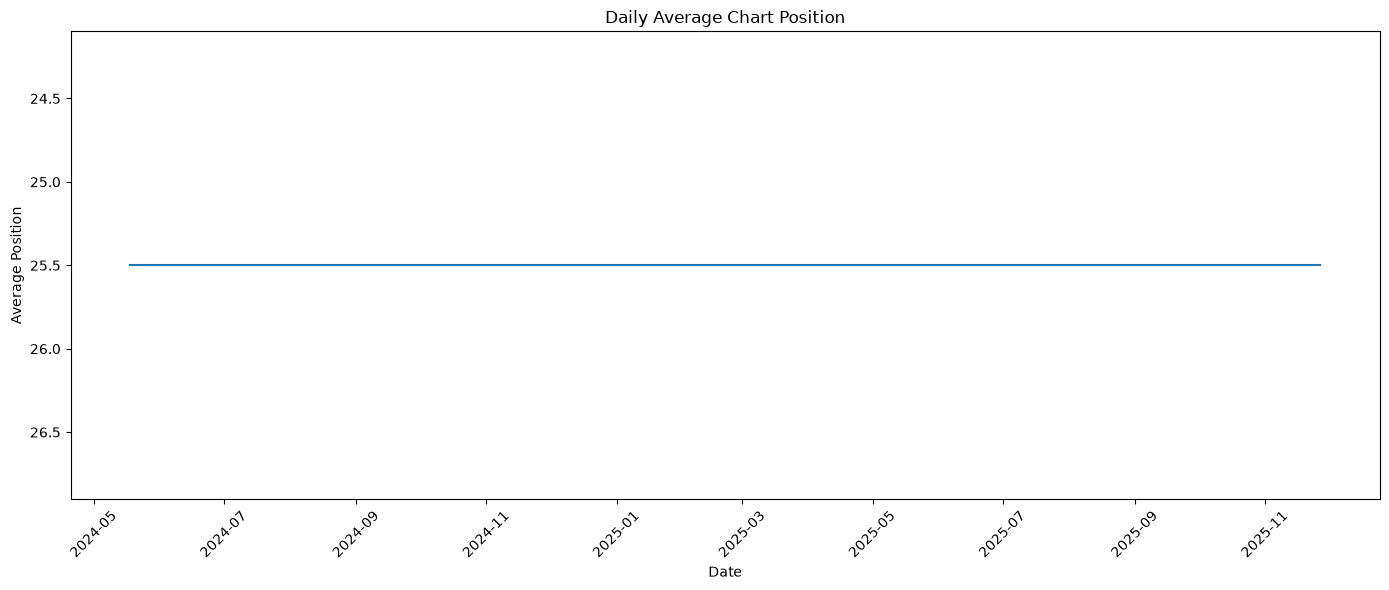

In [83]:
import matplotlib.pyplot as plt

# Daily average chart position

plt.figure(figsize=(14, 6))

plt.plot(
    daily_chart_stats["date"],
    daily_chart_stats["average_position"]
)

plt.gca().invert_yaxis()

plt.title("Daily Average Chart Position")
plt.xlabel("Date")
plt.ylabel("Average Position")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "daily_average_chart_position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

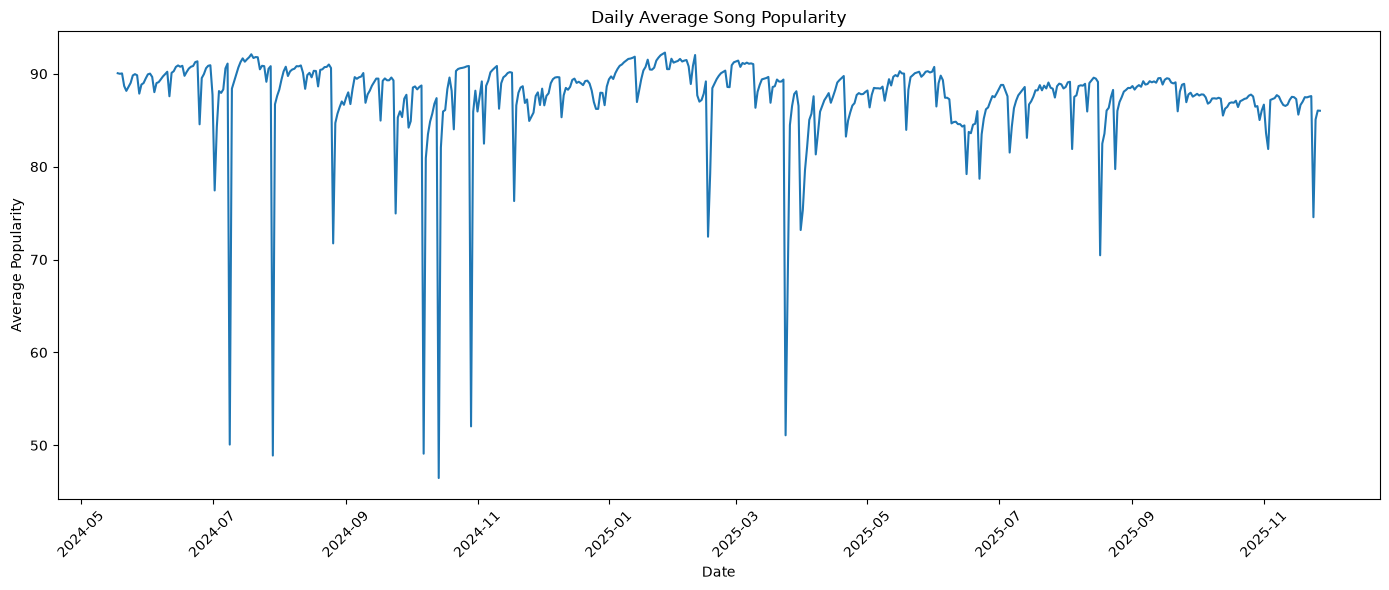

In [84]:
# Daily average popularity

plt.figure(figsize=(14, 6))

plt.plot(
    daily_chart_stats["date"],
    daily_chart_stats["average_popularity"]
)

plt.title("Daily Average Song Popularity")
plt.xlabel("Date")
plt.ylabel("Average Popularity")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "daily_average_popularity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

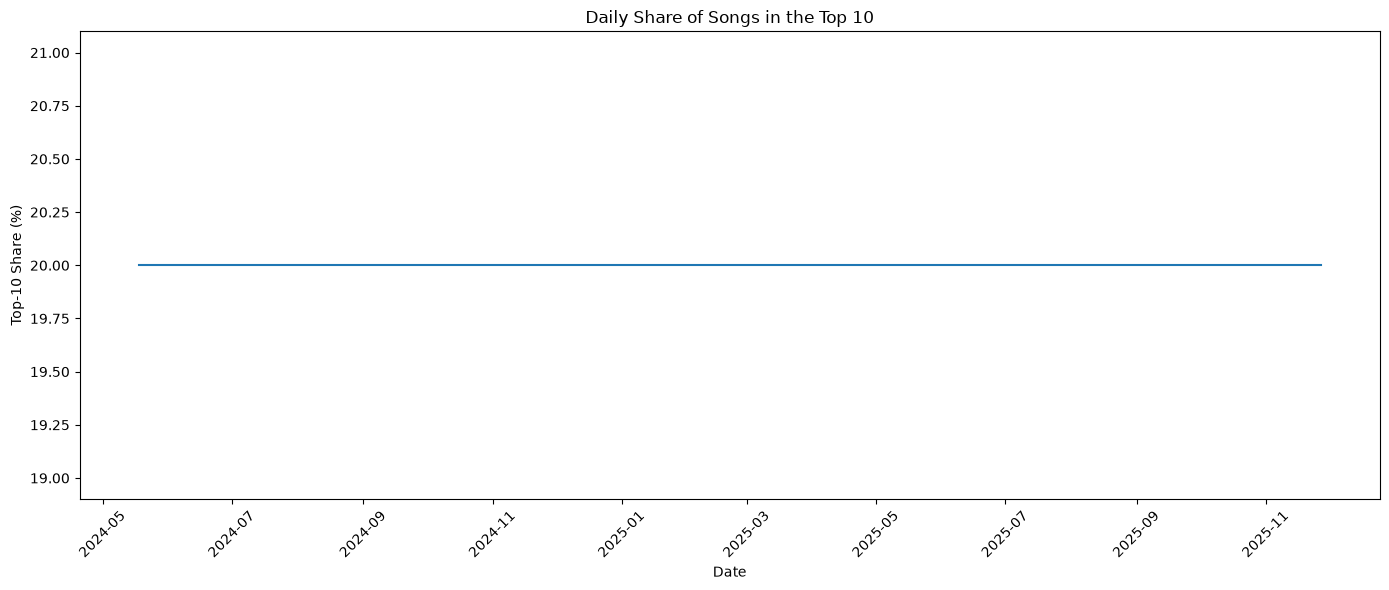

In [85]:
# Daily Top-10 share

plt.figure(figsize=(14, 6))

plt.plot(
    daily_chart_stats["date"],
    daily_chart_stats["top_10_share"] * 100
)

plt.title("Daily Share of Songs in the Top 10")
plt.xlabel("Date")
plt.ylabel("Top-10 Share (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "daily_top10_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

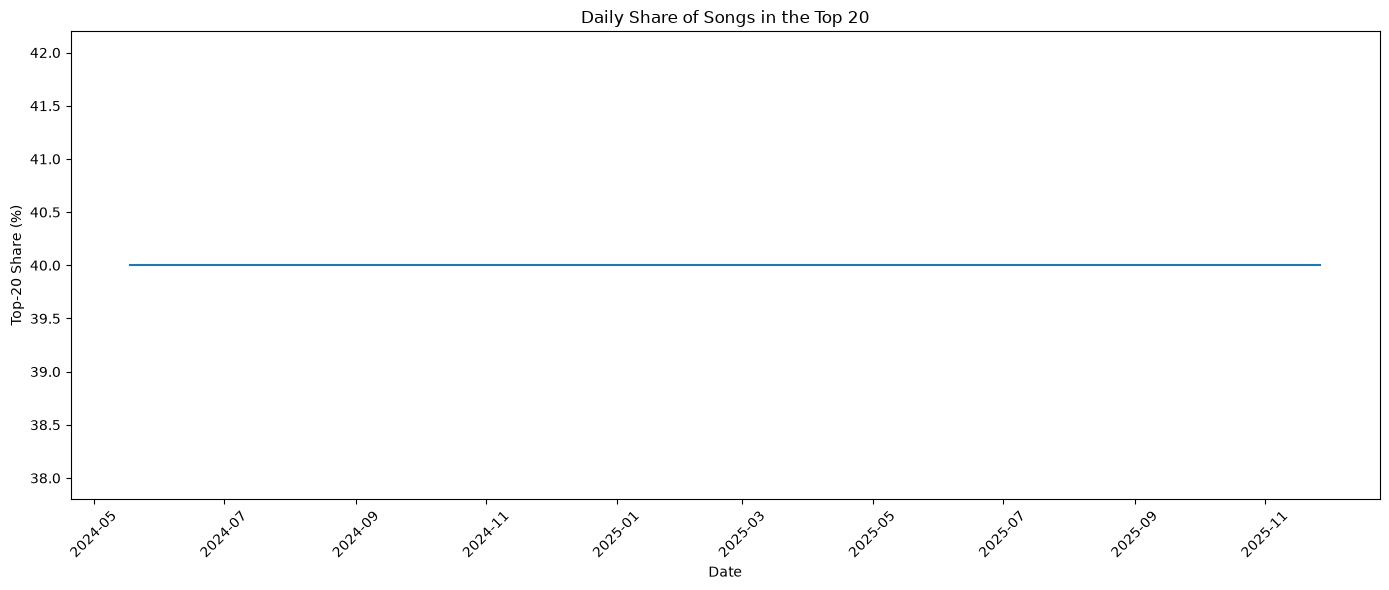

In [86]:
# Daily Top-20 share

plt.figure(figsize=(14, 6))

plt.plot(
    daily_chart_stats["date"],
    daily_chart_stats["top_20_share"] * 100
)

plt.title("Daily Share of Songs in the Top 20")
plt.xlabel("Date")
plt.ylabel("Top-20 Share (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "daily_top20_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

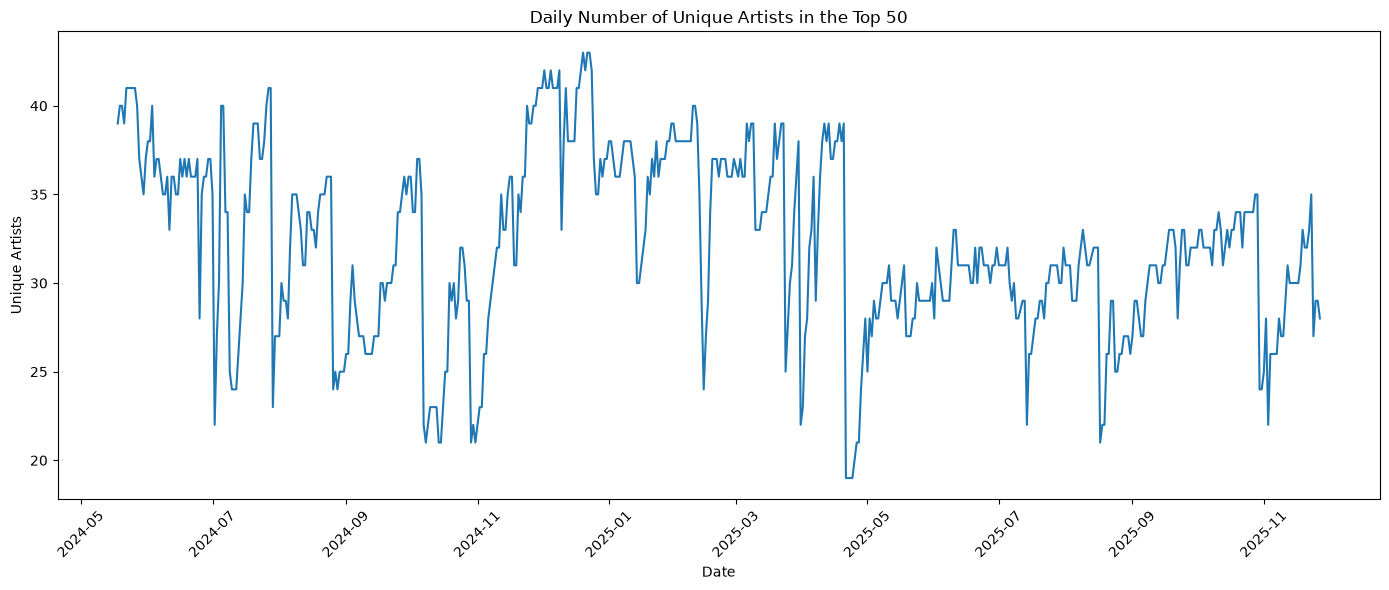

In [87]:
# Daily unique artist count

plt.figure(figsize=(14, 6))

plt.plot(
    daily_chart_stats["date"],
    daily_chart_stats["unique_artists"]
)

plt.title("Daily Number of Unique Artists in the Top 50")
plt.xlabel("Date")
plt.ylabel("Unique Artists")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "daily_unique_artists.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

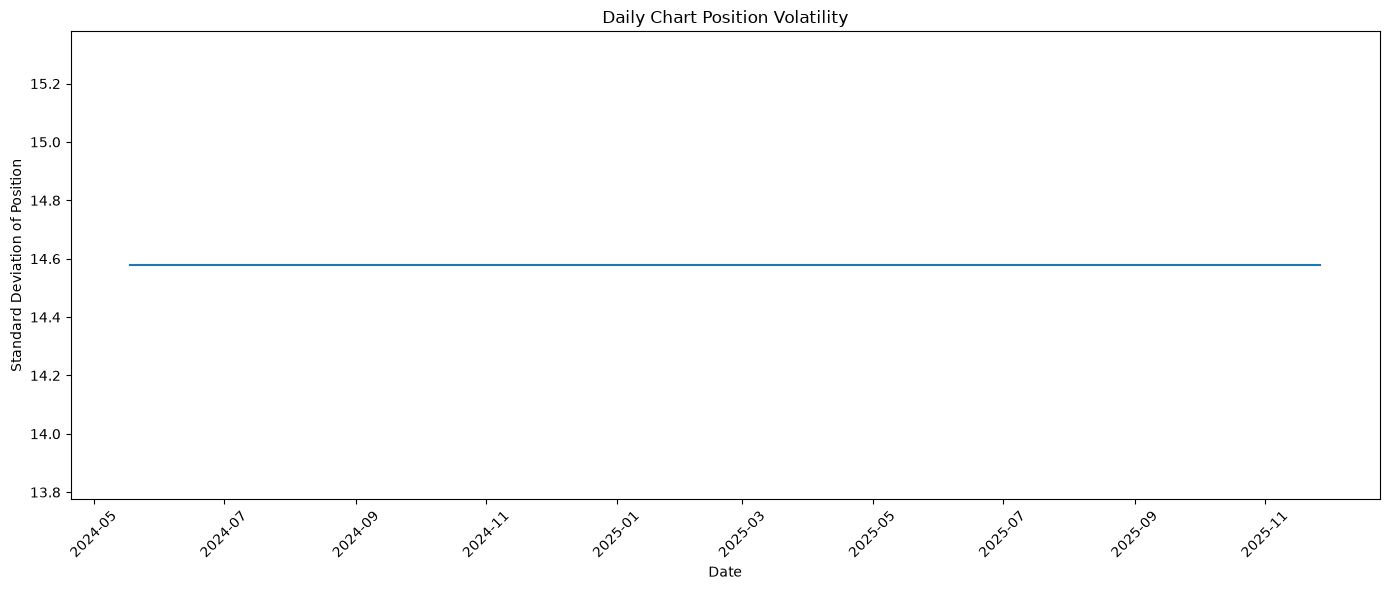

In [88]:
# Daily chart position volatility

plt.figure(figsize=(14, 6))

plt.plot(
    daily_chart_stats["date"],
    daily_chart_stats["position_volatility"]
)

plt.title("Daily Chart Position Volatility")
plt.xlabel("Date")
plt.ylabel("Standard Deviation of Position")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "daily_position_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

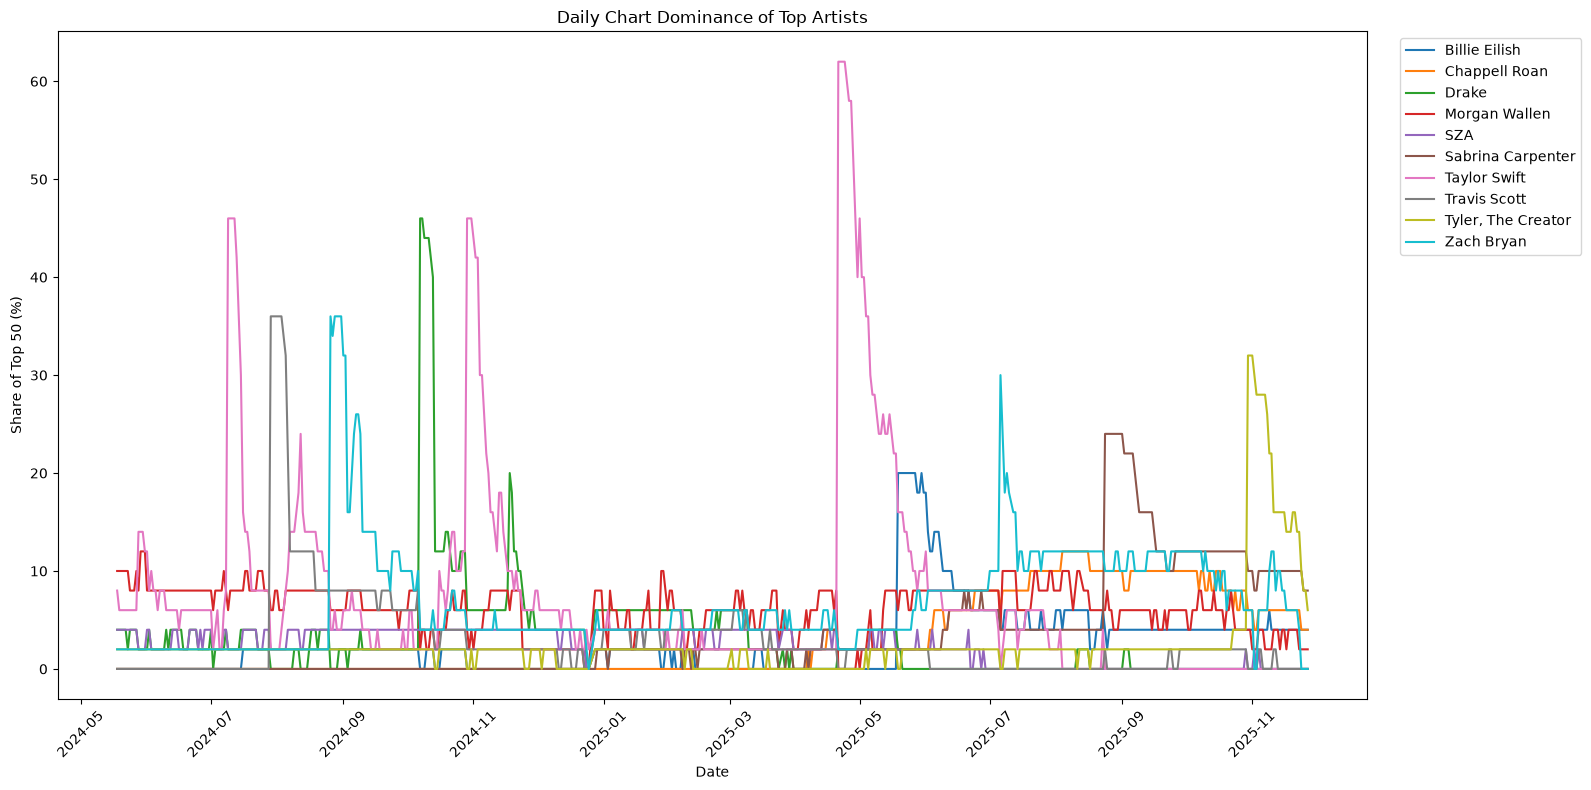

In [89]:
# Artist dominance over time

top_artists = (
    artist_summary
    .sort_values(
        "artist_dominance_index",
        ascending=False
    )
    .head(10)["artist"]
    .tolist()
)

dominance_top_artists = (
    daily_artist_dominance[
        daily_artist_dominance["artist"].isin(top_artists)
    ]
    .pivot(
        index="date",
        columns="artist",
        values="daily_dominance_percent"
    )
    .fillna(0)
)

plt.figure(figsize=(16, 8))

for artist in dominance_top_artists.columns:
    plt.plot(
        dominance_top_artists.index,
        dominance_top_artists[artist],
        label=artist
    )

plt.title("Daily Chart Dominance of Top Artists")
plt.xlabel("Date")
plt.ylabel("Share of Top 50 (%)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "artist_dominance_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
# Save daily chart statistics

daily_chart_stats.to_csv(
    tables_path / "daily_chart_stats.csv",
    index=False
)

print("Daily chart statistics saved successfully.")

Daily chart statistics saved successfully.


In [91]:
# Check generated figures

figure_files = sorted(
    figures_path.glob("*.png")
)

print("Number of figures created:", len(figure_files))

for file in figure_files:
    print("-", file.name)

Number of figures created: 7
- artist_dominance_over_time.png
- daily_average_chart_position.png
- daily_average_popularity.png
- daily_position_volatility.png
- daily_top10_share.png
- daily_top20_share.png
- daily_unique_artists.png


In [92]:
# Create final project KPI summary

kpi_summary = pd.DataFrame({
    "metric": [
        "Total observations",
        "Unique chart dates",
        "Unique songs",
        "Unique artists",
        "Average chart position",
        "Average popularity",
        "Average song duration (minutes)",
        "Explicit content share (%)",
        "Average days on chart",
        "Maximum observed song longevity (days)",
        "Maximum artist dominance (%)"
    ],
    "value": [
        len(df_analysis),
        df_analysis["date"].nunique(),
        df_analysis[["song", "artist"]].drop_duplicates().shape[0],
        df_analysis["artist"].nunique(),
        df_analysis["position"].mean(),
        df_analysis["popularity"].mean(),
        df_analysis["duration_minutes"].mean(),
        df_analysis["is_explicit"].mean() * 100,
        df_analysis["days_on_chart"].mean(),
        df_analysis["days_on_chart"].max(),
        artist_metrics["artist_dominance_index"].max()
    ]
})

print("Final project KPI summary:")

display(kpi_summary)

Final project KPI summary:


,metric,value
0,Total observations,27700.000000
1,Unique chart dates,554.000000
2,Unique songs,977.000000
3,Unique artists,297.000000
4,Average chart position,25.500000
5,Average popularity,87.652383
6,Average song duration (minutes),3.311016
7,Explicit content share (%),47.916968
8,Average days on chart,147.968809
9,Maximum observed song longevity (days),535.000000


In [93]:
# Create final song KPI table

song_kpi = (
    song_summary[
        [
            "song",
            "artist",
            "days_on_chart",
            "average_rank",
            "best_rank",
            "worst_rank",
            "rank_volatility",
            "average_popularity",
            "first_popularity",
            "last_popularity",
            "popularity_trend_score",
            "first_observed_date",
            "last_observed_date"
        ]
    ]
    .sort_values(
        ["days_on_chart", "average_rank"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("Final song KPI table:")

display(song_kpi.head(20))

Final song KPI table:


,song,artist,days_on_chart,average_rank,best_rank,worst_rank,rank_volatility,average_popularity,first_popularity,last_popularity,popularity_trend_score,first_observed_date,last_observed_date
0,Something in the Orange,Zach Bryan,535,26.304673,9,49,9.352375,88.366355,88,85,-3,2024-05-18,2025-11-23
1,Last Night,Morgan Wallen,491,22.613035,1,50,14.569361,85.674134,89,81,-8,2024-05-18,2025-10-22
2,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,445,13.916854,1,49,9.896528,90.076404,43,86,43,2024-08-26,2025-11-23
3,See You Again (feat. Kali Uchis),"Tyler, The Creator",443,29.340858,4,50,11.786710,91.083521,94,90,-4,2024-05-18,2025-11-26
4,Stick Season,Noah Kahan,413,18.322034,1,50,11.355484,91.079903,82,87,5,2024-09-27,2025-11-27
5,Cruel Summer,Taylor Swift,387,16.925065,1,50,13.642059,97.002584,92,93,1,2024-05-18,2025-08-03
6,Lose Control,Teddy Swims,328,23.536585,5,50,8.633829,90.908537,83,89,6,2024-12-28,2025-11-27
7,Thinkin’ Bout Me,Morgan Wallen,323,39.046440,21,50,7.136274,85.984520,87,83,-4,2024-05-18,2025-10-14
8,Beautiful Things,Benson Boone,306,14.738562,1,49,8.929796,90.800654,78,89,11,2025-01-21,2025-11-27
9,You Proof,Morgan Wallen,301,32.584718,9,50,12.043406,84.661130,86,83,-3,2024-05-18,2025-08-12


In [94]:
# Create final artist KPI table

artist_kpi = (
    artist_summary[
        [
            "artist",
            "unique_songs",
            "total_chart_days",
            "total_appearances",
            "artist_dominance_index",
            "average_rank",
            "best_rank",
            "average_popularity",
            "peak_daily_slots",
            "peak_daily_dominance_percent",
            "days_with_multiple_songs"
        ]
    ]
    .sort_values(
        "artist_dominance_index",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final artist KPI table:")

display(artist_kpi.head(20))

Final artist KPI table:


,artist,unique_songs,total_chart_days,total_appearances,artist_dominance_index,average_rank,best_rank,average_popularity,peak_daily_slots,peak_daily_dominance_percent,days_with_multiple_songs
0,Taylor Swift,96,225636,2014,7.270758,24.557100,1,87.096822,31,62.0,316
1,Zach Bryan,35,584680,1854,6.693141,25.619202,1,86.022114,18,36.0,435
2,Morgan Wallen,10,520154,1666,6.014440,30.610444,1,85.405762,6,12.0,469
3,Sabrina Carpenter,14,126738,966,3.487365,17.598344,1,90.198758,12,24.0,177
4,Drake,35,78320,838,3.025271,26.256563,1,84.608592,23,46.0,202
5,Chappell Roan,6,134218,794,2.866426,20.647355,1,88.664987,6,12.0,181
6,Travis Scott,31,115312,760,2.743682,25.744737,1,88.588158,18,36.0,157
7,Billie Eilish,12,91245,729,2.631769,20.362140,2,92.770919,10,20.0,187
8,"Tyler, The Creator",16,202137,705,2.545126,25.259574,1,88.394326,16,32.0,36
9,SZA,3,153894,646,2.332130,26.238390,3,91.668731,2,4.0,246


In [96]:
content_kpi = (
    df_analysis
    .groupby(
        ["is_explicit", "album_type"],
        observed=False
    )
    .agg(
        unique_songs=("song", "nunique"),
        observations=("song", "count"),
        average_rank=("position", "mean"),
        average_popularity=("popularity", "mean"),
        average_duration_minutes=("duration_minutes", "mean"),
        average_days_on_chart=("days_on_chart", "mean"),
        average_album_tracks=("total_tracks", "mean")
    )
    .reset_index()
)

content_kpi.to_csv(
    tables_path / "content_kpi.csv",
    index=False
)

print("content_kpi created and saved successfully.")
print("Shape:", content_kpi.shape)
display(content_kpi)

content_kpi created and saved successfully.
Shape: (5, 9)


,is_explicit,album_type,unique_songs,observations,average_rank,average_popularity,average_duration_minutes,average_days_on_chart,average_album_tracks
0,False,album,345,10330,25.711907,87.284124,3.297764,164.242304,17.487125
1,False,compilation,8,42,33.190476,78.380952,3.346217,10.285714,30.285714
2,False,single,120,4055,25.231073,89.856227,3.203354,157.890259,1.741800
3,True,album,410,9342,26.520338,85.986191,3.432839,145.300150,17.627810
4,True,single,121,3931,22.713559,90.405495,3.167008,102.783516,1.230984


In [97]:
# Save final KPI tables

kpi_summary.to_csv(
    tables_path / "kpi_summary.csv",
    index=False
)

song_kpi.to_csv(
    tables_path / "song_kpi.csv",
    index=False
)

artist_kpi.to_csv(
    tables_path / "artist_kpi.csv",
    index=False
)

content_kpi.to_csv(
    tables_path / "content_kpi.csv",
    index=False
)

print("Final KPI tables saved successfully.")

Final KPI tables saved successfully.


In [98]:
# Organize and save the processed analytical dataset

preferred_columns = [
    "date",
    "position",
    "song",
    "artist",
    "popularity",
    "duration_ms",
    "duration_minutes",
    "album_type",
    "total_tracks",
    "is_explicit",
    "year",
    "month",
    "day",
    "day_of_week",
    "previous_position",
    "rank_change",
    "is_entry",
    "is_exit",
    "days_on_chart",
    "average_rank",
    "best_rank",
    "rank_volatility",
    "average_popularity",
    "popularity_volatility",
    "first_popularity",
    "last_popularity",
    "popularity_trend_score",
    "chart_tier",
    "duration_category",
    "album_size_category",
    "rank_band"
]

processed_df = df_analysis[preferred_columns].copy()

processed_path = project_root / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

processed_file = processed_path / "Atlantic_United_States_processed.csv"

processed_df.to_csv(
    processed_file,
    index=False
)

print("Processed dataset saved:")
print(processed_file)

print("\nProcessed dataset shape:")
print(processed_df.shape)

Processed dataset saved:
C:\Users\ABC\OneDrive\Desktop\United-States-Top50-Playlist-Analysis\data\processed\Atlantic_United_States_processed.csv

Processed dataset shape:
(27700, 31)


In [99]:
# Final data-quality validation

print("===== FINAL DATA QUALITY CHECK =====")

print("\nRows:", len(processed_df))
print("Columns:", len(processed_df.columns))

print("\nDate range:")
print(processed_df["date"].min(), "to", processed_df["date"].max())

print("\nUnique dates:")
print(processed_df["date"].nunique())

print("\nRows per date:")
print(
    processed_df.groupby("date").size().value_counts().sort_index()
)

print("\nInvalid positions:")
print(
    ((processed_df["position"] < 1) | (processed_df["position"] > 50)).sum()
)

print("\nInvalid popularity values:")
print(
    ((processed_df["popularity"] < 0) | (processed_df["popularity"] > 100)).sum()
)

print("\nDuplicate song-artist-date combinations:")
print(
    processed_df.duplicated(
        subset=["date", "song", "artist"]
    ).sum()
)

print("\nMissing values:")
print(
    processed_df.isna().sum().sum()
)

print("\nFinal validation complete.")

===== FINAL DATA QUALITY CHECK =====

Rows: 27700
Columns: 31

Date range:
2024-05-18 00:00:00 to 2025-11-27 00:00:00

Unique dates:
554

Rows per date:
50    554
Name: count, dtype: int64

Invalid positions:
0

Invalid popularity values:
0

Duplicate song-artist-date combinations:
0

Missing values:
2268

Final validation complete.


In [100]:
# Check final output files

print("===== OUTPUT FILE CHECK =====")

print("\nTables:")

for file in sorted(tables_path.glob("*.csv")):
    print("-", file.name)

print("\nFigures:")

for file in sorted(figures_path.glob("*.png")):
    print("-", file.name)

print("\nProcessed data:")

for file in sorted(processed_path.glob("*.csv")):
    print("-", file.name)

===== OUTPUT FILE CHECK =====

Tables:
- album_size_summary.csv
- album_type_summary.csv
- artist_by_chart_days.csv
- artist_by_unique_songs.csv
- artist_kpi.csv
- artist_summary.csv
- best_peak_songs.csv
- content_attribute_summary.csv
- content_correlation.csv
- content_kpi.csv
- daily_artist_dominance.csv
- daily_chart_stats.csv
- duration_statistics.csv
- duration_summary.csv
- explicit_content_share.csv
- explicit_summary.csv
- fast_risers.csv
- kpi_summary.csv
- largest_declines.csv
- long_lasting_high_rank.csv
- longest_chart_songs.csv
- peak_rank_popularity.csv
- popularity_by_rank_band.csv
- popularity_by_tier.csv
- popularity_declines.csv
- popularity_rank_correlation.csv
- popularity_trend_summary.csv
- rank_popularity_stability.csv
- song_kpi.csv
- song_level_correlation.csv
- song_lifecycle.csv
- song_summary.csv
- trend_longevity.csv
- volatility_correlation.csv
- volatility_summary.csv

Figures:
- artist_dominance_over_time.png
- daily_average_chart_position.png
- daily_